## OBJECTIF BUSINESS
Développer un modèle de prédiction automatique des prix de vente pour :

- Estimer rapidement le prix d'une nouvelle propriété
- Réduire les erreurs d'estimation (actuellement ±15%)
- Gagner du temps (actuellement 2h par estimation)

## 📊 KPI À ATTEINDRE

- Précision : Erreur moyenne < 10% du prix réel
- RMSE : < 30,000$ (notre marge d'erreur acceptable)
- R² : > 0.85 (85% de la variance expliquée)
## QUESTIONS BUSINESS À RÉPONDRE

- Quels sont les 5 facteurs les PLUS importants qui influencent le prix ?
- Quel type de propriété se vend le plus cher en moyenne ?
- Y a-t-il des outliers (propriétés surévaluées/sous-évaluées) ?
- Le quartier/localisation a-t-il un gros impact ?
- Peut-on faire confiance aux prédictions du modèle ?

## 🎨 **LIVRABLES ATTENDUS**

- Rapport EDA (PDF/notebook) avec insights business
- Modèle entraîné (pickle ou joblib)
- Documentation : Comment utiliser le modèle
- Dashboard/graphiques : Prédictions vs Réel

--- 

In [1]:
# import des datasets 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import missingno as miss
import seaborn as sns 
from scipy import stats
import statsmodels.api as sm 
from statsmodels.formula.api import ols  
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression , Ridge , Lasso , ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV , cross_val_score , train_test_split
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


In [2]:
# importer le dataset
df = pd.read_csv('train.csv')
print(df)

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Utilities  ... PoolArea PoolQC  Fe

## **ANALYSE EXPLORATOIRE DE DONNEES**

In [3]:
#inspections rapide de la base 
df.info()
df.shape
df.head(19)

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [4]:
# statistiques descriptives
df.describe(include = 'all')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


##### Analyse détaillée de la target 
- quelle est la distribution de la target? 
- la distribution est elle normale ? 
- y'a t'il des outliers (visualisation rapide avec boxplot)
- c'est quoi le min , max , la médiane , la moyenne , et l'écart-type( obtenu avec describe )

In [5]:
print('-'*50)
minimun = df["SalePrice"].min()
maximun = df["SalePrice"].max()
moyenne  = df["SalePrice"].mean()
mediane = df["SalePrice"].median()
ecart_type = df["SalePrice"].std()
print(f'la moyenne est{moyenne} , la mediane est {mediane} le min est {minimun} , le maximum est {maximun} , écart type est {ecart_type}')

--------------------------------------------------
la moyenne est180921.19589041095 , la mediane est 163000.0 le min est 34900 , le maximum est 755000 , écart type est 79442.50288288662


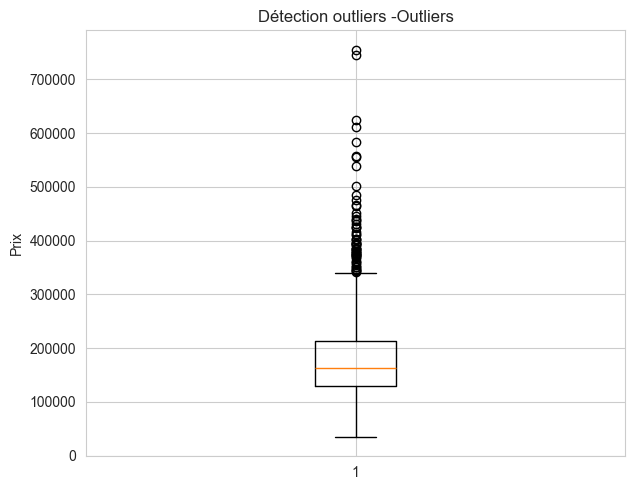

<Figure size 640x480 with 0 Axes>

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.boxplot(df["SalePrice"])
plt.ylabel("Prix")
plt.title('Détection outliers -Outliers')
plt.tight_layout()
plt.show()
plt.savefig('images/boxplot_outliers')


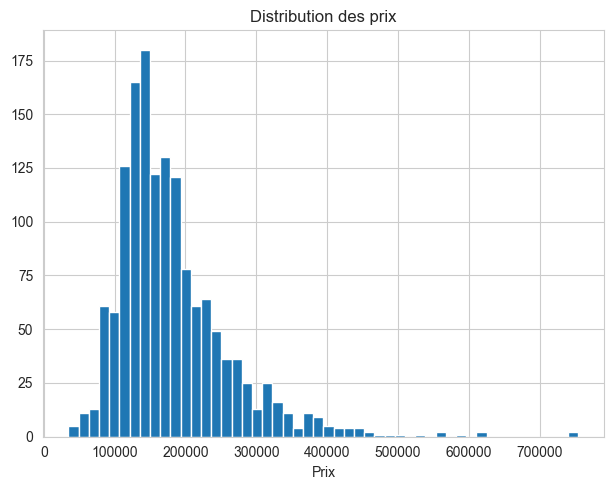

<Figure size 640x480 with 0 Axes>

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.hist(df["SalePrice"] , bins=50)
plt.xlabel("Prix")
plt.title("Distribution des prix")
plt.tight_layout()
plt.show()
plt.savefig('images/distribution')


In [8]:
#vérifier la normalité 
skewness = stats.skew(df["SalePrice"])
kurtosis = stats.kurtosis(df["SalePrice"] , fisher = False)
exces_kustosis = stats.kurtosis(df["SalePrice"])
print(f"skewness = {skewness}")
print(f"kurtosis = {kurtosis}")
print(f"exces de kutoses = {exces_kustosis}")

skewness = 1.880940746034036
kurtosis = 9.509812011089439
exces de kutoses = 6.509812011089439


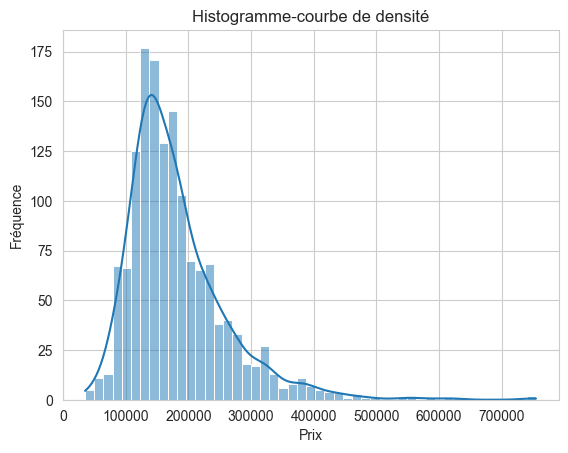

<Figure size 640x480 with 0 Axes>

In [9]:
# analyse graphique pour vérifier la normalité de la target
plt.figure()
sns.histplot(df["SalePrice"], kde = True)
plt.xlabel("Prix")
plt.ylabel("Fréquence")
plt.title("Histogramme-courbe de densité")
plt.show()
plt.savefig("images/histogramme_target")

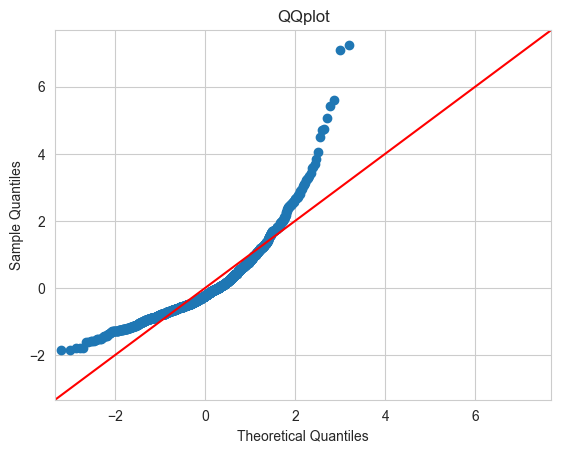

<Figure size 640x480 with 0 Axes>

In [10]:
sm.qqplot(df["SalePrice"] , line= '45' , fit = True)
plt.title("QQplot")
plt.show()
plt.savefig("images/qqplot_target")

La variable "SalaPrice " ne suit potentiellement pas une loi normale nous allons vérifier cela avec plusieurs tests statistiques

In [11]:
# définir le niveau de signification
alpha = 0.05 
# effectuer les tests de normalité 
shapiro_test = stats.shapiro(df["SalePrice"])
ks_test= stats.kstest(df["SalePrice"] , 'norm')
# créer un tableau 
test_results = pd.DataFrame({
    'Nom du test' :['Shapiro-Wilk','Kolgomorov-Smirov'],
    'Statistique de test' : [shapiro_test[0] , ks_test.statistic],
    'p-value':[shapiro_test[1] , ks_test.pvalue],
    'Normalité':['oui' if shapiro_test[1]>alpha else 'Non',
                'Oui' if ks_test.pvalue > alpha else 'Non']                     
 })
print(test_results)

         Nom du test  Statistique de test       p-value Normalité
0       Shapiro-Wilk             0.869671  3.206141e-33       Non
1  Kolgomorov-Smirov             1.000000  0.000000e+00       Non


 La target ne suit pas une distribution normale

### Véfification des valeurs manquantes

In [12]:
sum = df.isnull().sum()
proportion = df.isnull().sum() / len(df) *100
missing_data = pd.DataFrame({
    'Colonne': df.columns,
    'Nombre de valeurs manquantes': sum,
    'Proportion de valeurs manquantes (%)': proportion
})
print(missing_data)

                     Colonne  Nombre de valeurs manquantes  \
Id                        Id                             0   
MSSubClass        MSSubClass                             0   
MSZoning            MSZoning                             0   
LotFrontage      LotFrontage                           259   
LotArea              LotArea                             0   
...                      ...                           ...   
MoSold                MoSold                             0   
YrSold                YrSold                             0   
SaleType            SaleType                             0   
SaleCondition  SaleCondition                             0   
SalePrice          SalePrice                             0   

               Proportion de valeurs manquantes (%)  
Id                                         0.000000  
MSSubClass                                 0.000000  
MSZoning                                   0.000000  
LotFrontage                            

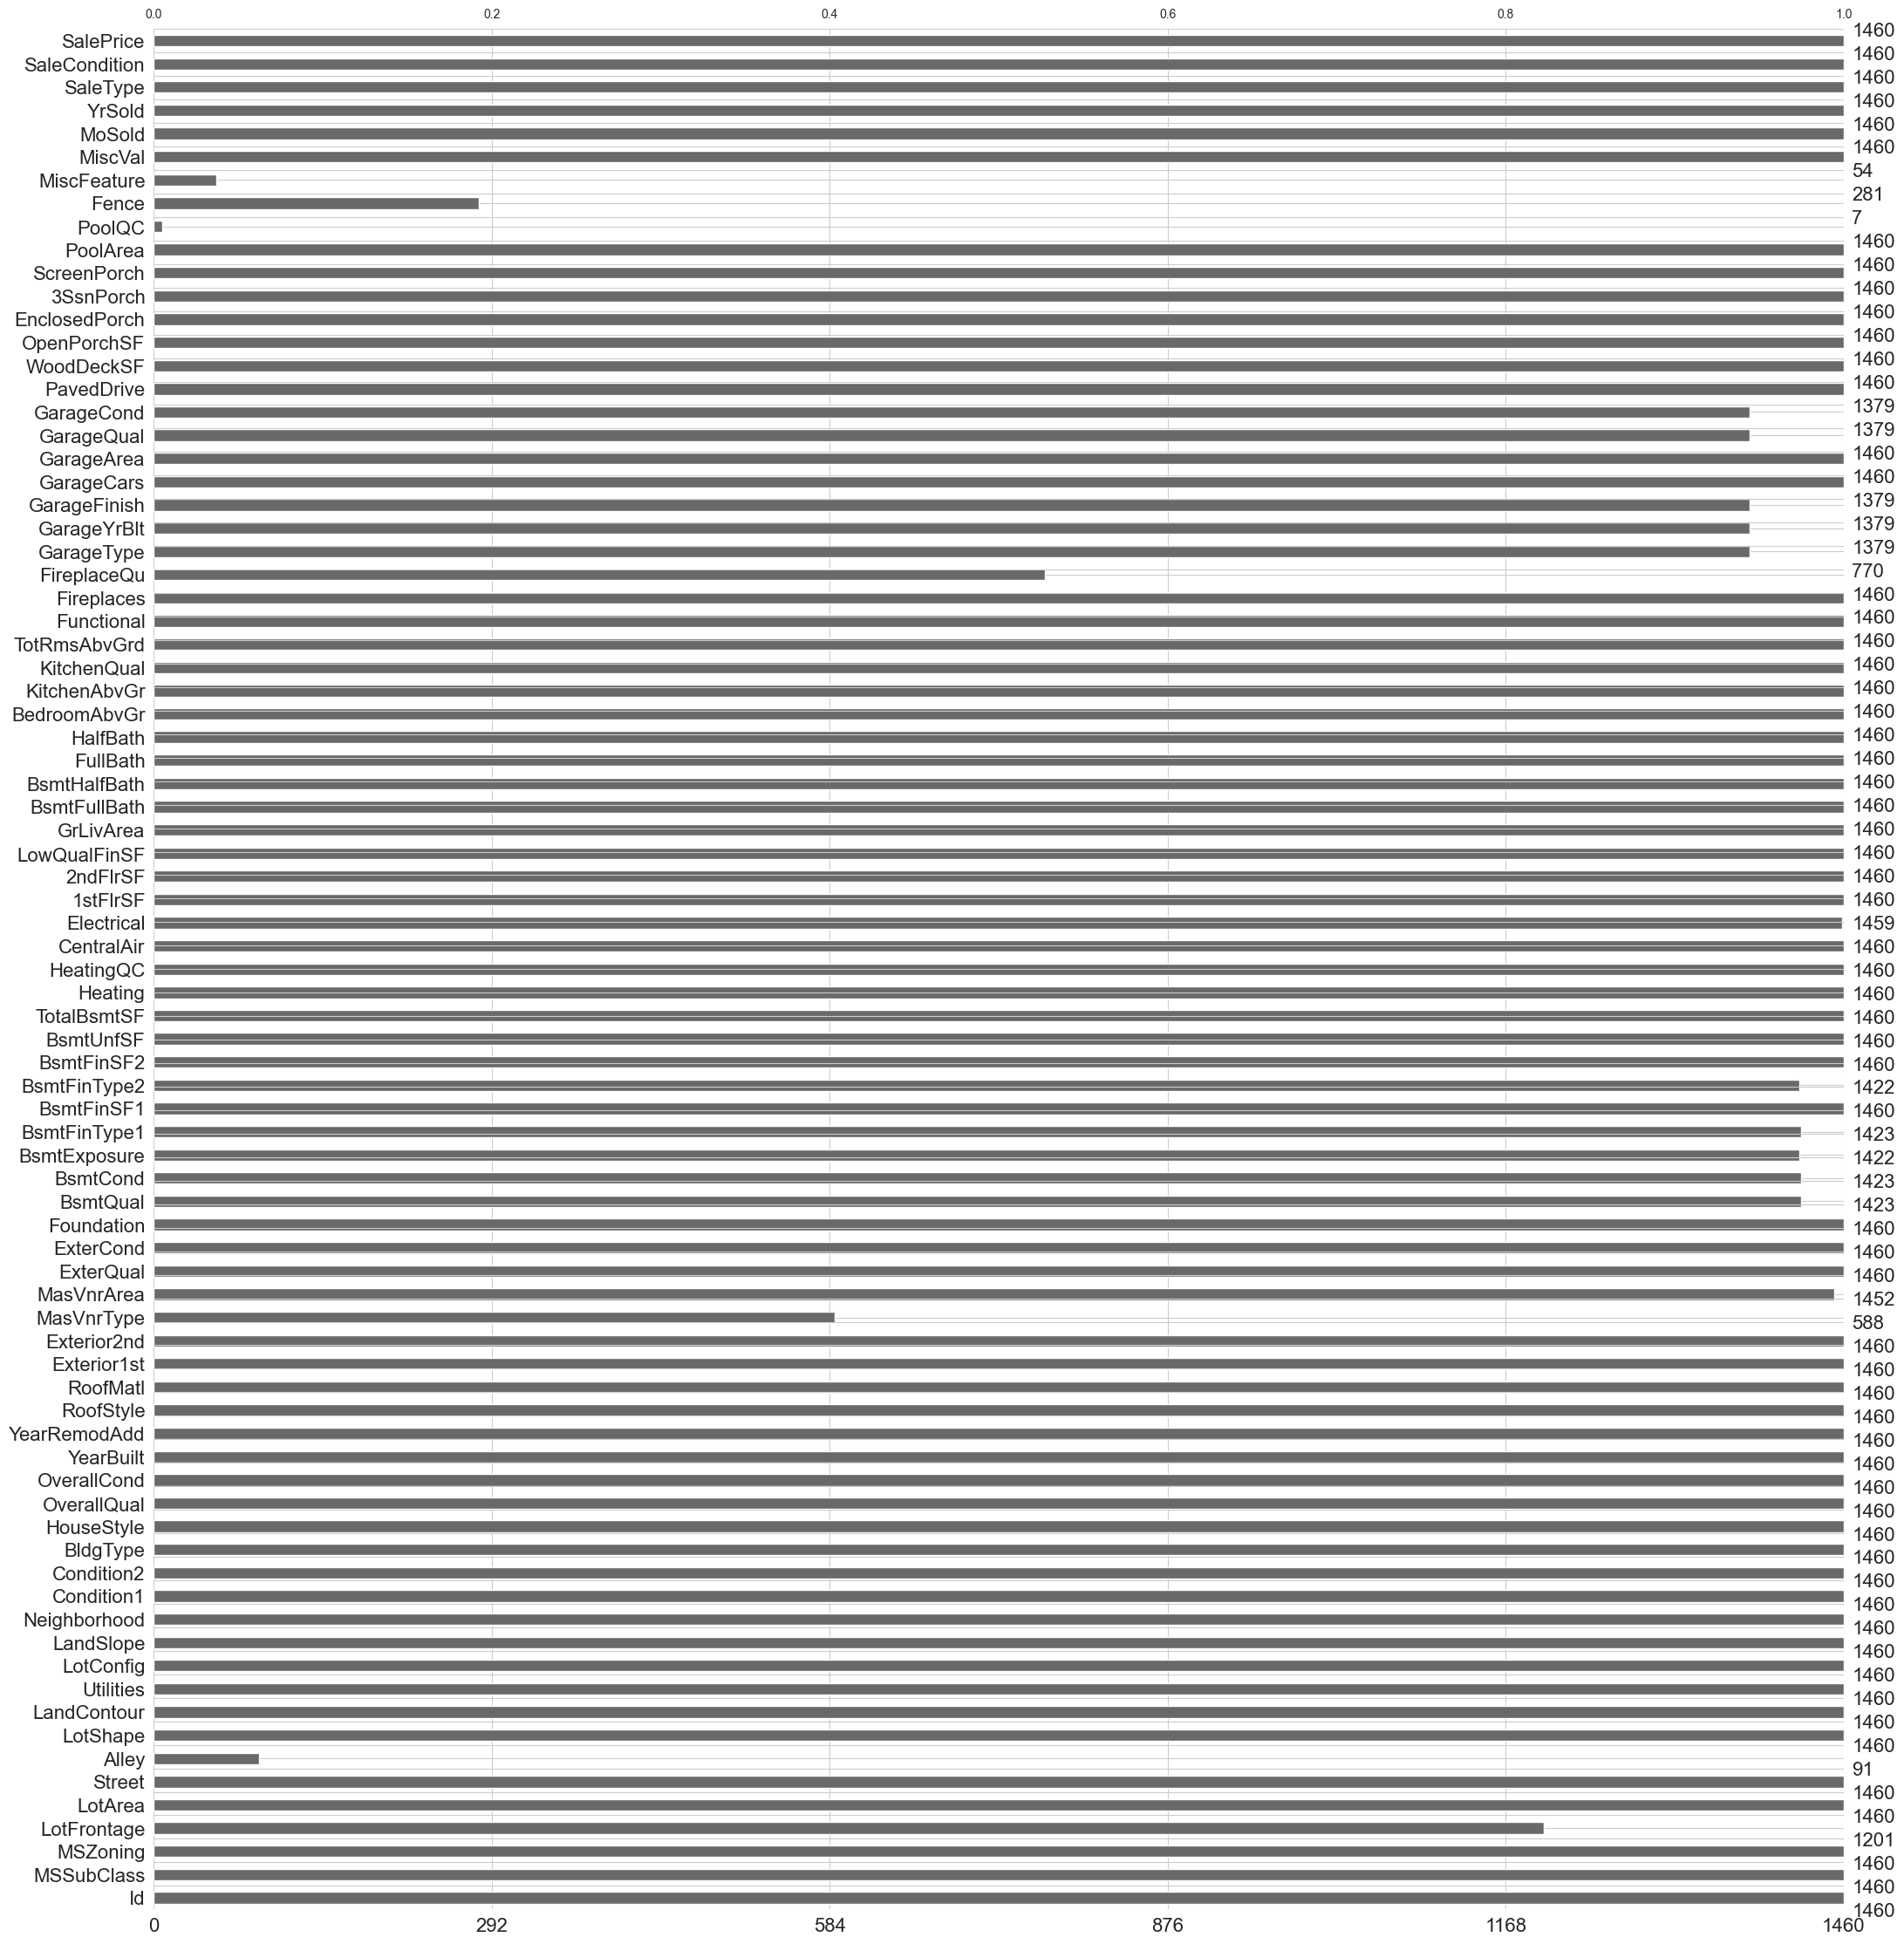

In [13]:
# visualisation des données manquantes 
miss.bar(df)
plt.savefig('images/visualisation_DM')

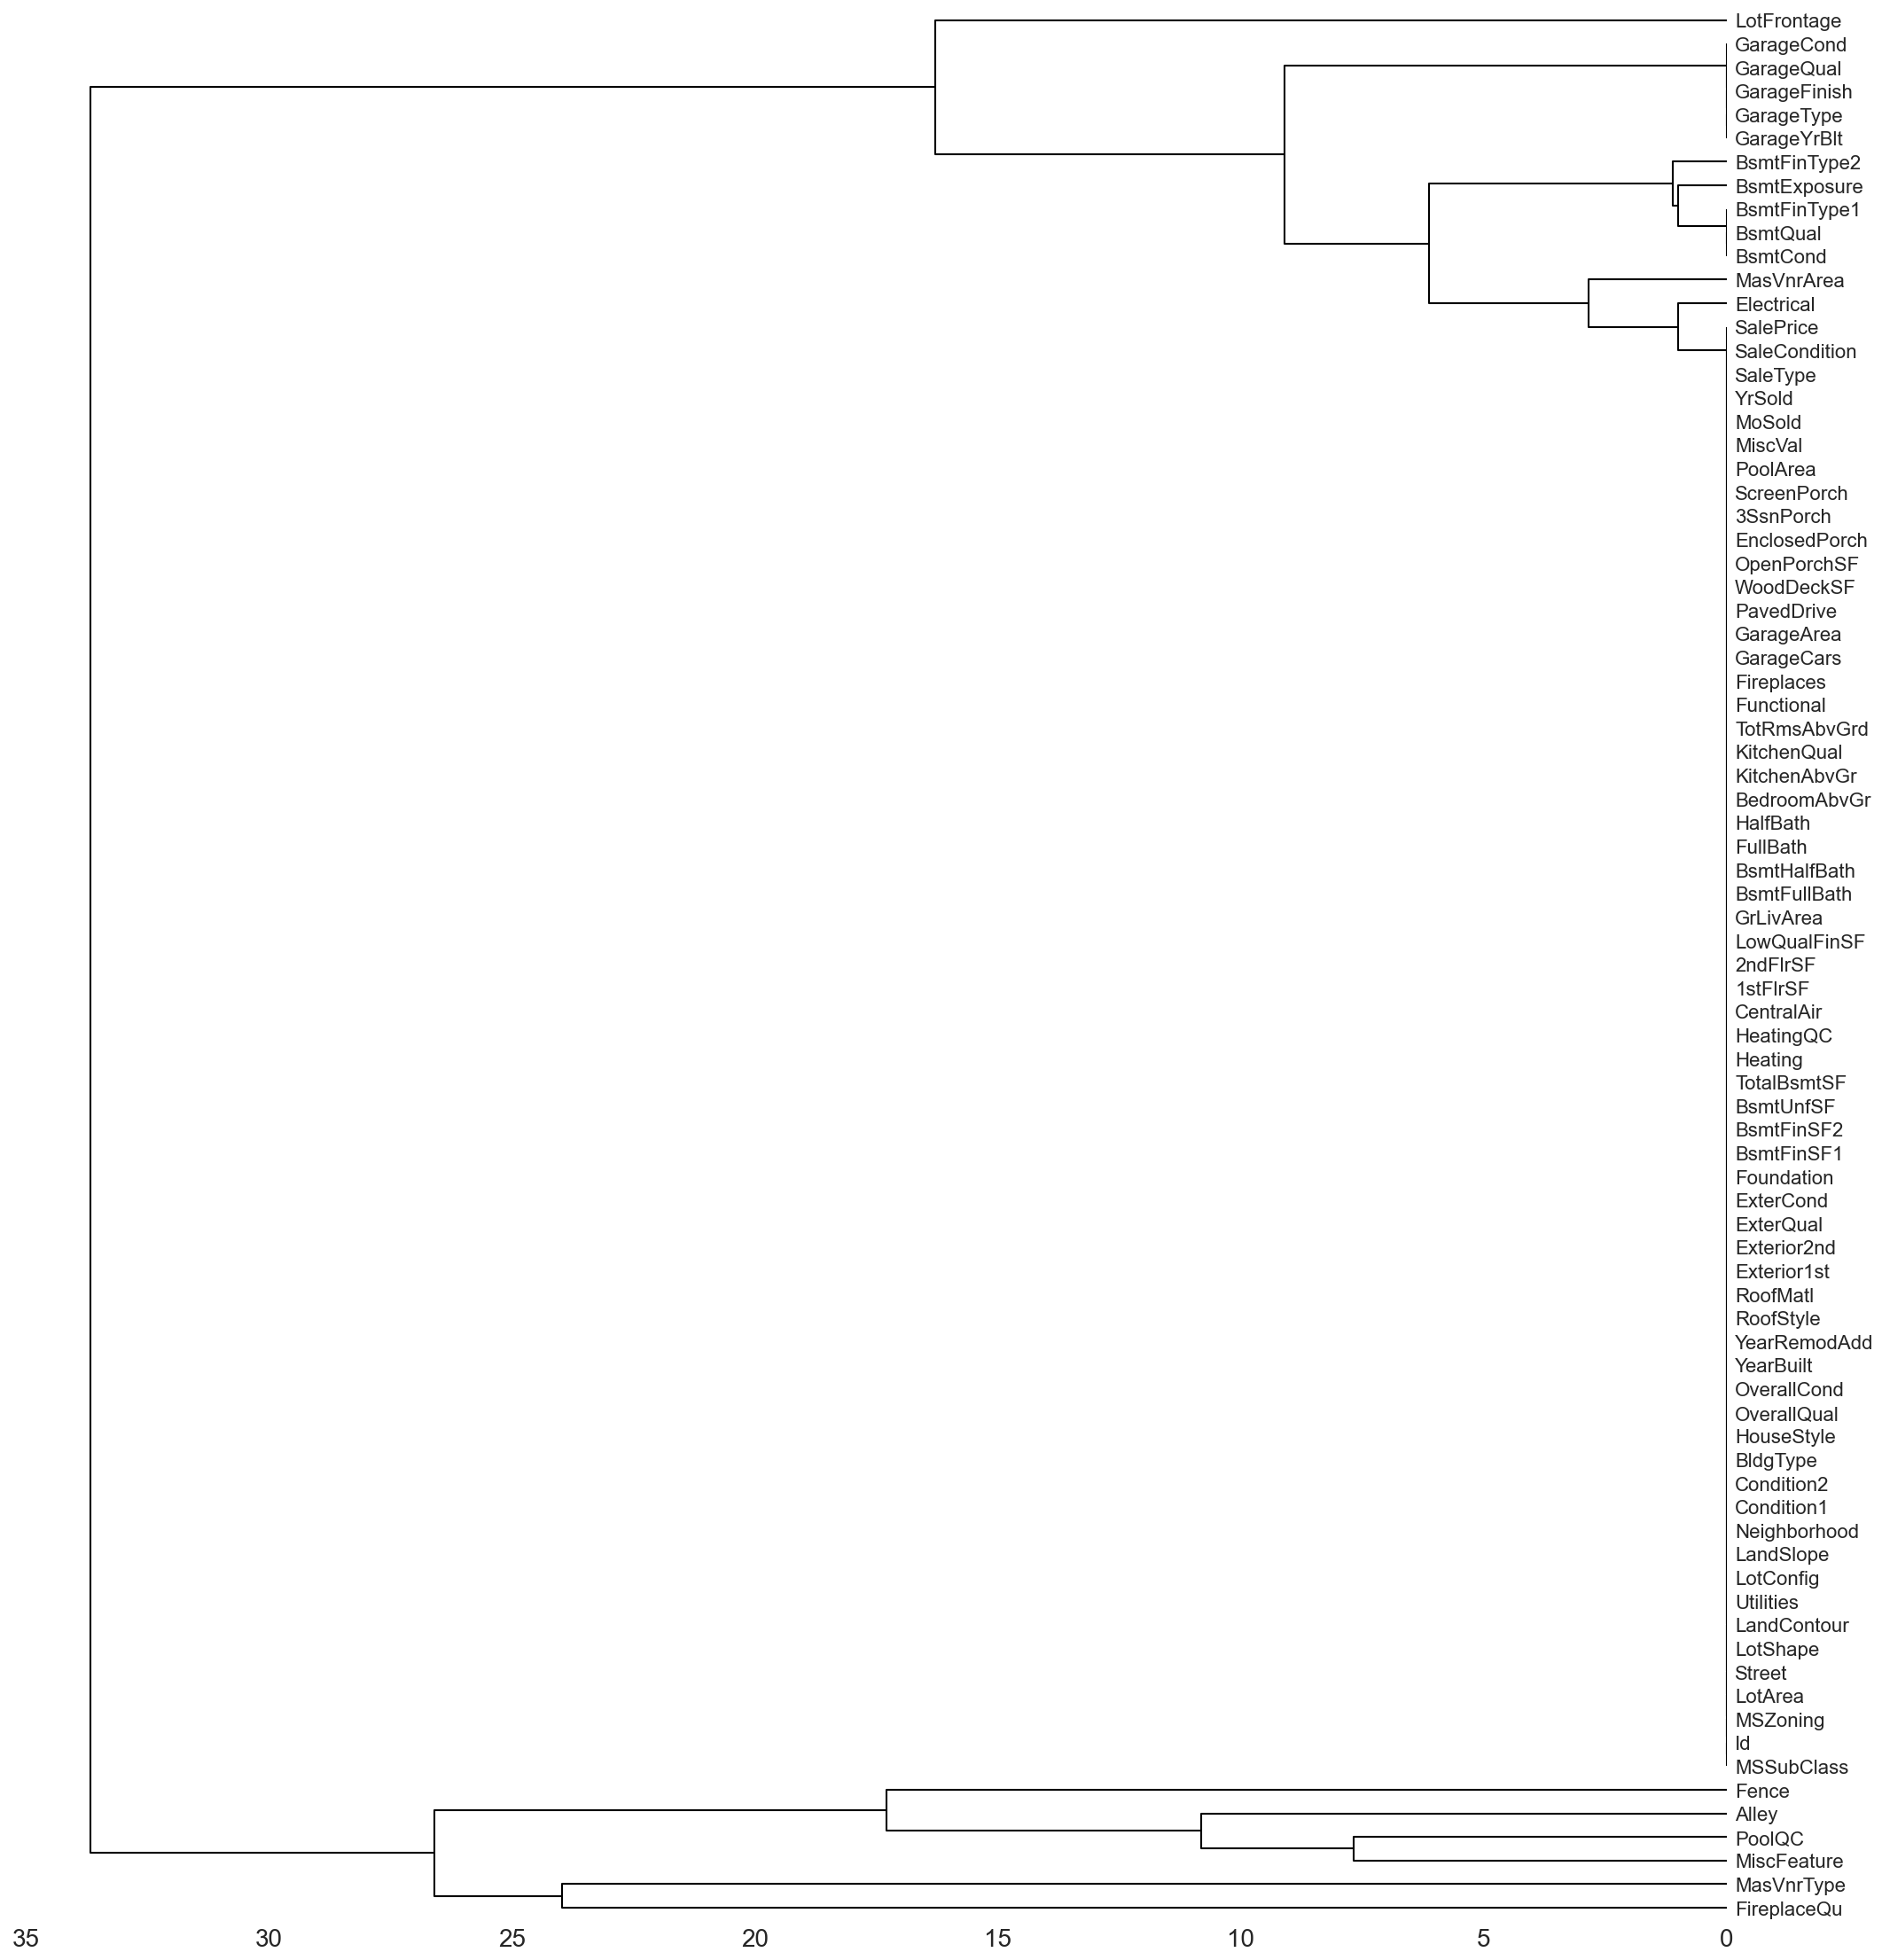

In [14]:
miss.dendrogram(df)
plt.savefig('images/dendogram_DM')

<Axes: >

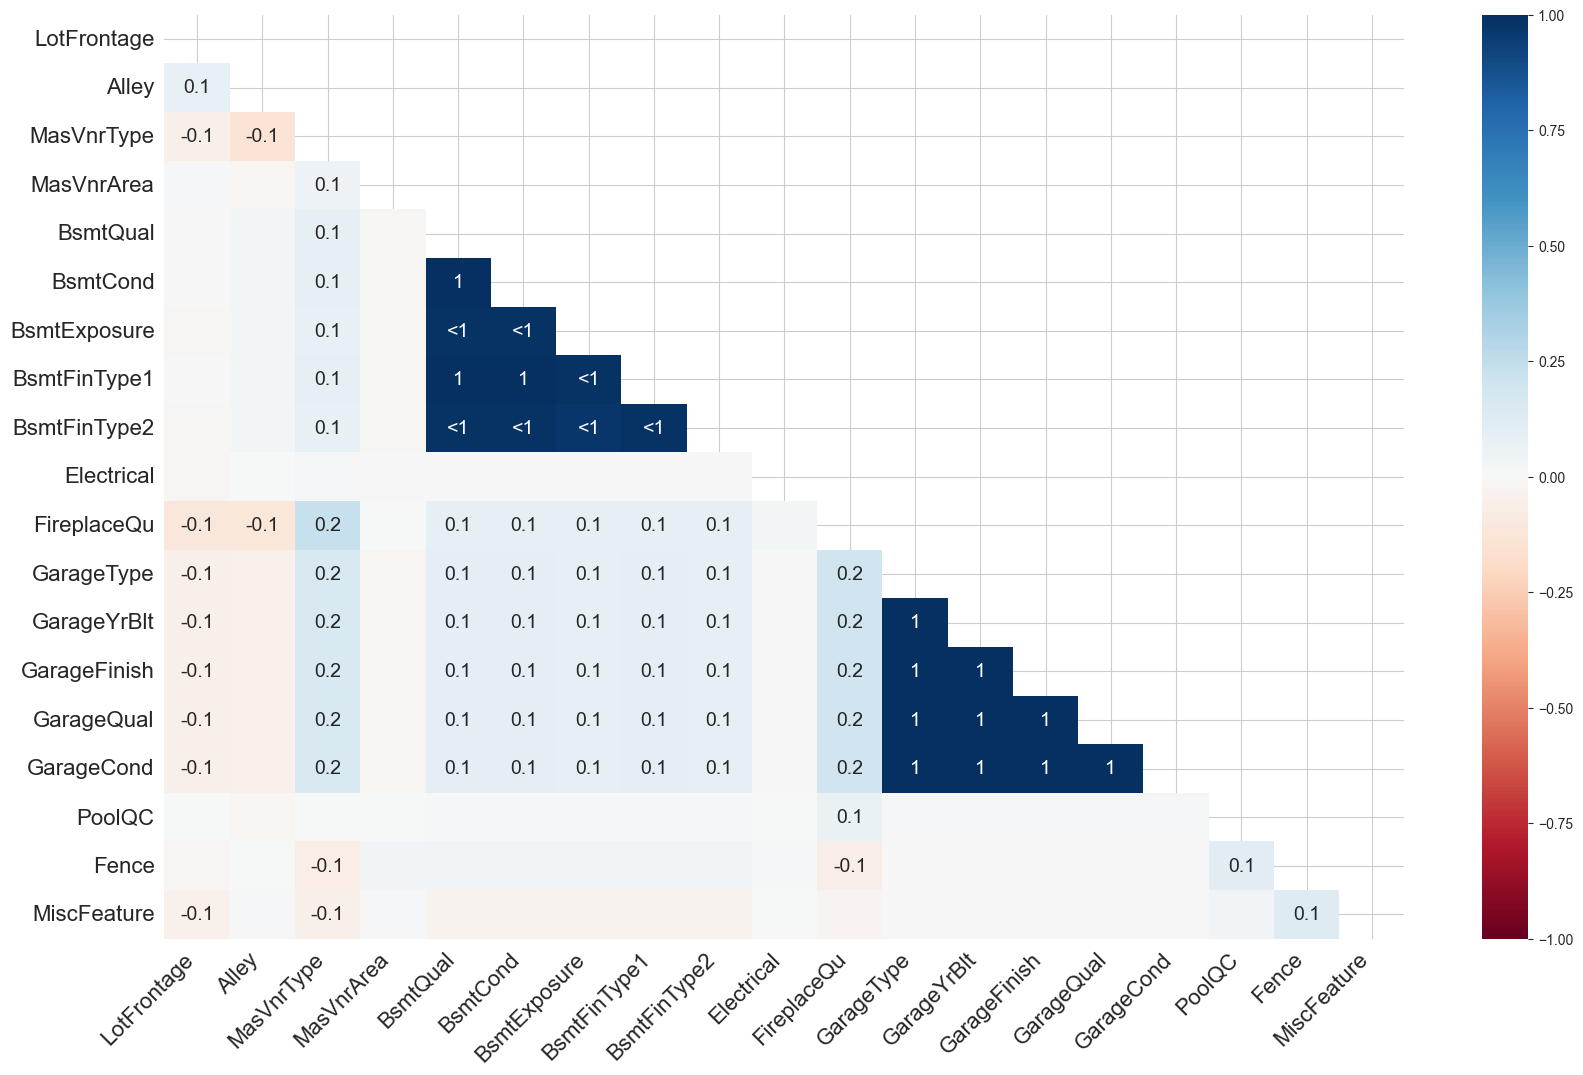

In [15]:
miss.heatmap(df)

déterminons à présent le type de valeurs manquantes que nous avons (MCAR , MNAR , MAR )

In [16]:
# Méthode alternative pour détecter les colonnes MCAR
import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency

def approx_mcar(df):
    mcars = []
    for col in df.columns[df.isnull().any()]:
        is_missing = df[col].isnull()
        dependent = False
        for other in df.columns:
            if other == col:
                continue
            if pd.api.types.is_numeric_dtype(df[other]):
                g1 = df.loc[is_missing, other].dropna()
                g2 = df.loc[~is_missing, other].dropna()
                if len(g1) > 0 and len(g2) > 0:
                    _, p = ttest_ind(g1, g2, equal_var=False)
                    if p < 0.05:
                        dependent = True
                        break
            else:
                tab = pd.crosstab(is_missing, df[other])
                if tab.shape[1] > 1:
                    _, p, _, _ = chi2_contingency(tab)
                    if p < 0.05:
                        dependent = True
                        break
        if not dependent:
            mcars.append(col)
    return mcars

mcars = approx_mcar(df)
print("Colonnes approximativement MCAR :", mcars)

Colonnes approximativement MCAR : []


In [17]:
# Détection MAR (Missing At Random) : Les données manquent de manière aléatoire, mais la probabilité de manque est liée à d'autres variables observées.
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency

def detect_mar(df):
    mar_vars = []

    for col in df.columns:
        if df[col].isnull().sum() == 0:
            continue  # Passe si aucune valeur manquante

        # Crée un indicateur temporaire pour les NaN
        df['is_missing'] = df[col].isnull()

        # Liste des colonnes à tester (exclut la variable elle-même et l’indicateur)
        cols_to_test = [c for c in df.columns if c != col and c != 'is_missing']

        for other in cols_to_test:
            # Variable numérique
            if pd.api.types.is_numeric_dtype(df[other]):
                group1 = df[df['is_missing'] == True][other].dropna()
                group2 = df[df['is_missing'] == False][other].dropna()
                if len(group1) > 0 and len(group2) > 0:
                    stat, p = ttest_ind(group1, group2, equal_var=False)
                    if p < 0.05:
                        mar_vars.append((col, other, 'numérique', p))

            # Variable catégorielle
            else:
                tab = pd.crosstab(df['is_missing'], df[other])
                if tab.shape[1] > 1:  # au moins 2 modalités
                    chi2_stat, p, dof, expected = chi2_contingency(tab)
                    if p < 0.05:
                        mar_vars.append((col, other, 'catégoriel', p))

        # Supprime la colonne temporaire
        df.drop(columns=['is_missing'], inplace=True)

    # Résumé
    if mar_vars:
        print("Variables MAR détectées (p < 0.05) :")
        for var, other, typ, p in mar_vars:
            print(f"  - '{var}' dépend de '{other}' ({typ}), p={p:.4f}")
    else:
        print("Aucune variable MAR détectée.")

# Utilisation
detect_mar(df)


Variables MAR détectées (p < 0.05) :
  - 'LotFrontage' dépend de 'MSZoning' (catégoriel), p=0.0007
  - 'LotFrontage' dépend de 'LotArea' (numérique), p=0.0022
  - 'LotFrontage' dépend de 'LotShape' (catégoriel), p=0.0000
  - 'LotFrontage' dépend de 'LandContour' (catégoriel), p=0.0000
  - 'LotFrontage' dépend de 'LotConfig' (catégoriel), p=0.0000
  - 'LotFrontage' dépend de 'LandSlope' (catégoriel), p=0.0000
  - 'LotFrontage' dépend de 'Neighborhood' (catégoriel), p=0.0000
  - 'LotFrontage' dépend de 'Condition1' (catégoriel), p=0.0001
  - 'LotFrontage' dépend de 'HouseStyle' (catégoriel), p=0.0175
  - 'LotFrontage' dépend de 'YearBuilt' (numérique), p=0.0167
  - 'LotFrontage' dépend de 'RoofStyle' (catégoriel), p=0.0007
  - 'LotFrontage' dépend de 'RoofMatl' (catégoriel), p=0.0316
  - 'LotFrontage' dépend de 'Exterior1st' (catégoriel), p=0.0000
  - 'LotFrontage' dépend de 'Exterior2nd' (catégoriel), p=0.0000
  - 'LotFrontage' dépend de 'MasVnrType' (catégoriel), p=0.0000
  - 'LotFront

les données manquantes sont principalement MAR 

# détection des variables coréélees avec la taget 

Corrélations avec SalePrice :
 SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
Kitchen

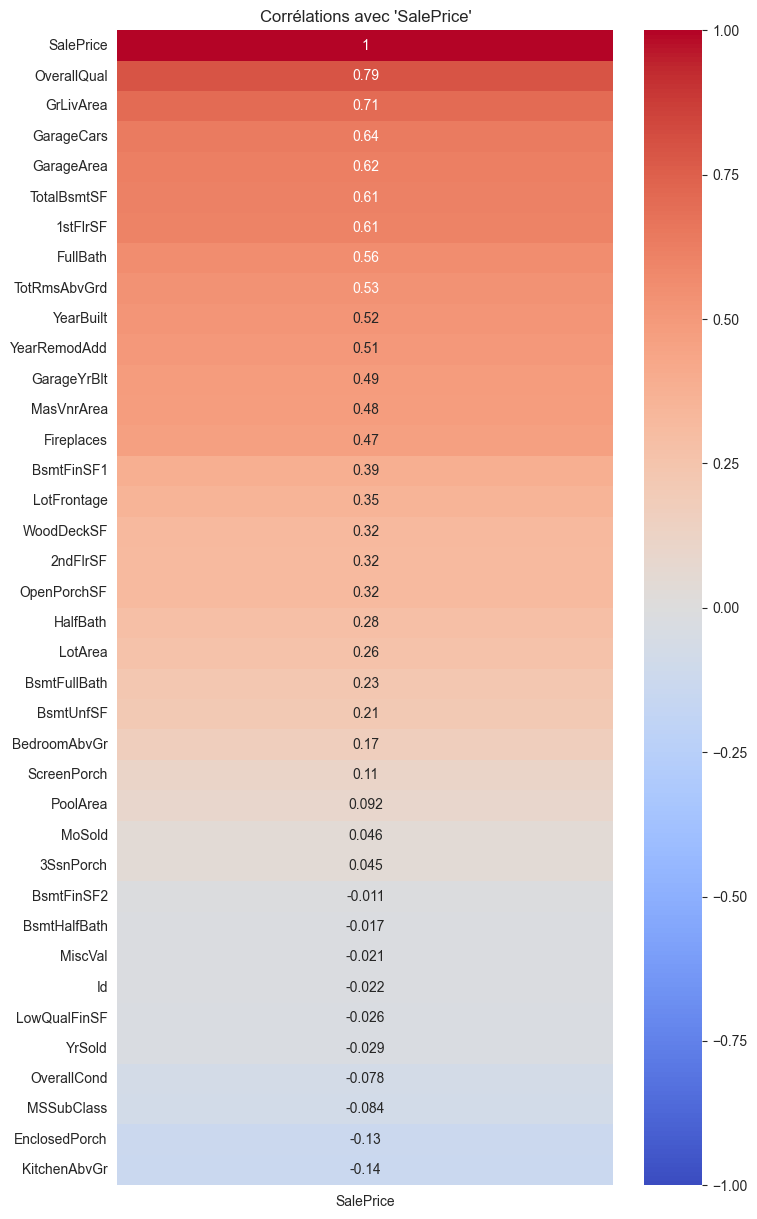

In [18]:
# Variable cible
target_var = 'SalePrice'

# Calcul de la matrice de corrélation
corr_matrix = df.corr(numeric_only=True)

# Tri des corrélations par rapport à la variable cible
corr_with_target = corr_matrix[target_var].sort_values(ascending=False)

print("Corrélations avec", target_var, ":\n", corr_with_target)

# Visualisation avec Seaborn (heatmap filtrée)
plt.figure(figsize=(8, 15))
sns.heatmap(corr_matrix[[target_var]].sort_values(by=target_var, ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f"Corrélations avec '{target_var}'")
plt.show()

Variables fortement corrélées avec 'SalePrice' (|corr| >= 0.4):

OverallQual     0.809829
GrLivArea       0.731310
GarageCars      0.690711
YearBuilt       0.652682
GarageArea      0.649379
FullBath        0.635957
TotalBsmtSF     0.602725
GarageYrBlt     0.593788
1stFlrSF        0.575408
YearRemodAdd    0.571159
TotRmsAbvGrd    0.532586
Fireplaces      0.519247
OpenPorchSF     0.477561
LotArea         0.456461
MasVnrArea      0.421309
LotFrontage     0.409076
Name: SalePrice, dtype: float64


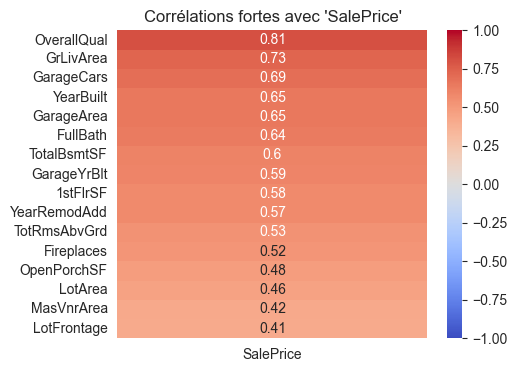

In [19]:
# Affichage des variables fortement corrélées avec la variable cible avec un certain seuil de corrélation et avec la méthode de Spearman pour les corrélations monotones (non linéaires)
# Paramètres
target_var = 'SalePrice'   # Variable cible
threshold = 0.4        # Seuil de corrélation

# Calcul de la matrice de corrélation
corr_matrix = df.corr( method='spearman',numeric_only=True)

# Extraction des corrélations avec la variable cible
corr_with_target = corr_matrix[target_var].drop(target_var)  # On enlève la corrélation avec elle-même

# Filtrage selon le seuil
strong_corr = corr_with_target[abs(corr_with_target) >= threshold].sort_values(ascending=False)

print(f"Variables fortement corrélées avec '{target_var}' (|corr| >= {threshold}):\n")
print(strong_corr)

# Visualisation uniquement des variables retenues
if not strong_corr.empty:
    plt.figure(figsize=(5, 4))
    sns.heatmap(corr_matrix.loc[strong_corr.index, [target_var]],
                annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"Corrélations fortes avec '{target_var}'")
    plt.show()
else:
    print("Aucune variable ne dépasse le seuil de corrélation.")



## Détection des valeurs aberrantes 

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest

# Séparer les features numériques
X_num = df.select_dtypes(include=[np.number]).drop(columns=['Id'], errors='ignore')
y = df['SalePrice']  # ta variable cible

# Split
X_train, X_test, y_train, y_test = train_test_split(X_num, y, test_size=0.2, random_state=42)

# IsolationForest sur train uniquement
iso_forest = IsolationForest(contamination=0.1, random_state=42)
outlier_labels_train = iso_forest.fit_predict(X_train)
X_train_clean = X_train[outlier_labels_train == 1]
y_train_clean = y_train[outlier_labels_train == 1]

# Appliquer sur test
outlier_labels_test = iso_forest.predict(X_test)
X_test_clean = X_test[outlier_labels_test == 1]
y_test_clean = y_test[outlier_labels_test == 1]
print(X_test_clean)

      MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
892           20         70.0     8414            6            8       1963   
1105          60         98.0    12256            8            5       1994   
413           30         56.0     8960            5            6       1927   
522           50         50.0     5000            6            7       1947   
1036          20         89.0    12898            9            5       2007   
...          ...          ...      ...          ...          ...        ...   
479           30         50.0     5925            4            7       1937   
1361          20        124.0    16158            7            5       2005   
802           60         63.0     8199            7            5       2005   
651           70         60.0     9084            4            5       1940   
722           20         70.0     8120            4            7       1970   

      YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFin

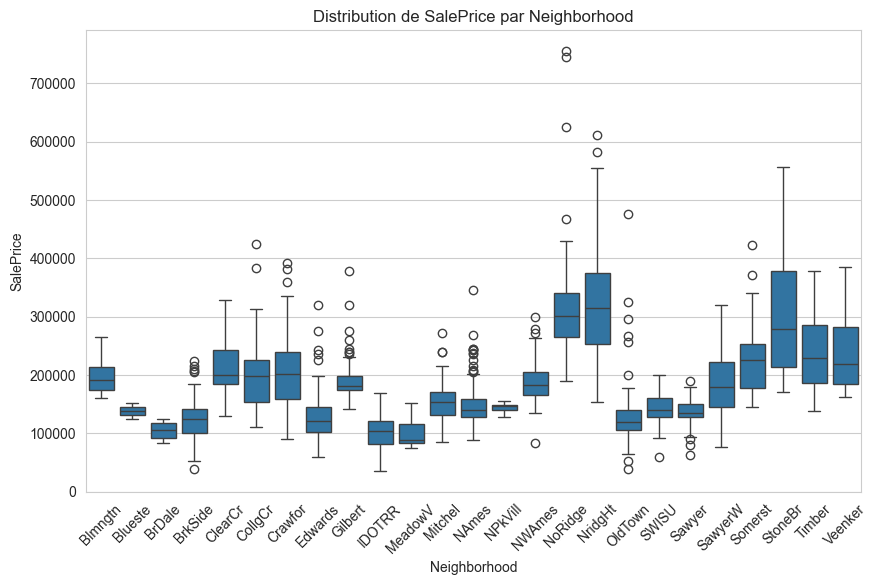

=== Tableau ANOVA ===
                       sum_sq      df          F         PR(>F)
C(Neighborhood)  5.023606e+12    24.0  71.784865  1.558600e-225
Residual         4.184305e+12  1435.0        NaN            NaN
=== Résumé Régression OLS ===
                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.538
Method:                 Least Squares   F-statistic:                     71.78
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          1.56e-225
Time:                        10:40:50   Log-Likelihood:                -17968.
No. Observations:                1460   AIC:                         3.599e+04
Df Residuals:                    1435   BIC:                         3.612e+04
Df Model:                          24                                         
Covariance Type:            nonrobust        

<Figure size 640x480 with 0 Axes>

In [21]:
#  1. Nettoyage des données
data = df[['SalePrice', 'Neighborhood']].copy()

# Forcer les bons types
data['SalePrice'] = pd.to_numeric(data['SalePrice'], errors='coerce')
data['Neighborhood'] = data['Neighborhood'].astype('category')

# Supprimer les valeurs manquantes
data = data.dropna()

#  2. Visualisation
plt.figure(figsize=(10,6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=data)
plt.xticks(rotation=45)
plt.title("Distribution de SalePrice par Neighborhood")
plt.show()
plt.savefig('images/boxplot_neighborhood_saleprice')

#  3. ANOVA
model = ols('SalePrice ~ C(Neighborhood)', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== Tableau ANOVA ===")
print(anova_table)

#  4. Régression OLS avec dummies (version propre)
X = pd.get_dummies(data['Neighborhood'], drop_first=True, dtype=float)
y = data['SalePrice'].astype(float)

X = sm.add_constant(X)

ols_model = sm.OLS(y, X).fit()

print("=== Résumé Régression OLS ===")
print(ols_model.summary())

In [22]:
# comprendre le type de maison qui a le prix de vente le plus élevé en moyenne
df.groupby("HouseStyle")["SalePrice"].mean().sort_values(ascending=False)

HouseStyle
2.5Fin    220000.000000
2Story    210051.764045
1Story    175985.477961
SLvl      166703.384615
2.5Unf    157354.545455
1.5Fin    143116.740260
SFoyer    135074.486486
1.5Unf    110150.000000
Name: SalePrice, dtype: float64

- Oui il existe des propriétés surévaluées/sous_évaluées
- Les 5 facteurs qui influencent le prix sont OverallQual,GrLivArea    GarageCars,YearBuilt,GarageArea 
- La localisation a un d'impact énorme sur le prix R² = 0,546 
-  le type de propriété qui se vends le plus chère en moyenne est le 2.5Fin    


## Traitement des variables 

Ici il est question de  traiter les valeurs manqauntes , d'encoder les variables catégorielles , et de traiter les valeurs aberrantes 
Mais une bonne façon de traiter les valeurs aberrantes est d'entrainer le modèle avec les outliers et ensuite de le faire sans ces derniers afin de comprendre s'ils ont un impact 
Toutefois pour éviter le data leakage en voulant faire le traitement des données manquantes ou des outliers ou l'encodage nous allons passer par des pipelines 

## Sélection des features 

Ici nous allons directement intégrer la sélection des features dans le pipeline 

## Entrainement des différents modèles 

📊 Variables numériques : 36
📝 Variables catégorielles : 43

✂️ Split effectué :
  Train : 1168 lignes
  Test : 292 lignes

🧹 CONSTRUCTION DU PREPROCESSOR
✅ ColumnTransformer créé :
  - Pipeline numérique : Imputer (median) + StandardScaler
  - Pipeline catégoriel : Imputer (mode) + OneHotEncoder

🤖 RECHERCHE DU MEILLEUR MODÈLE (GridSearchCV)
🔍 GridSearchCV en cours (cela peut prendre quelques minutes)...
Fitting 5 folds for each of 49 candidates, totalling 245 fits

✅ MEILLEUR MODÈLE TROUVÉ :
  Modèle : RandomForestRegressor
  Paramètres : {'feature_selection__k': 'all', 'model': RandomForestRegressor(random_state=42), 'model__max_depth': None, 'model__n_estimators': 100}
  Score CV (R²) : 0.8390

📊 PERFORMANCES SUR TEST :
  RMSE : $28,547
  MAE : $17,598
  R² : 0.8938

📊 COMPARAISON DE TOUS LES MODÈLES

Linear Regression:
  RMSE: $33,000
  MAE: $20,581
  R²: 0.8580
  CV R²: 0.7909 (±0.0723)

Ridge (alpha=10):
  RMSE: $33,137
  MAE: $20,457
  R²: 0.8568
  CV R²: 0.7948 (±0.0767)

Lasso

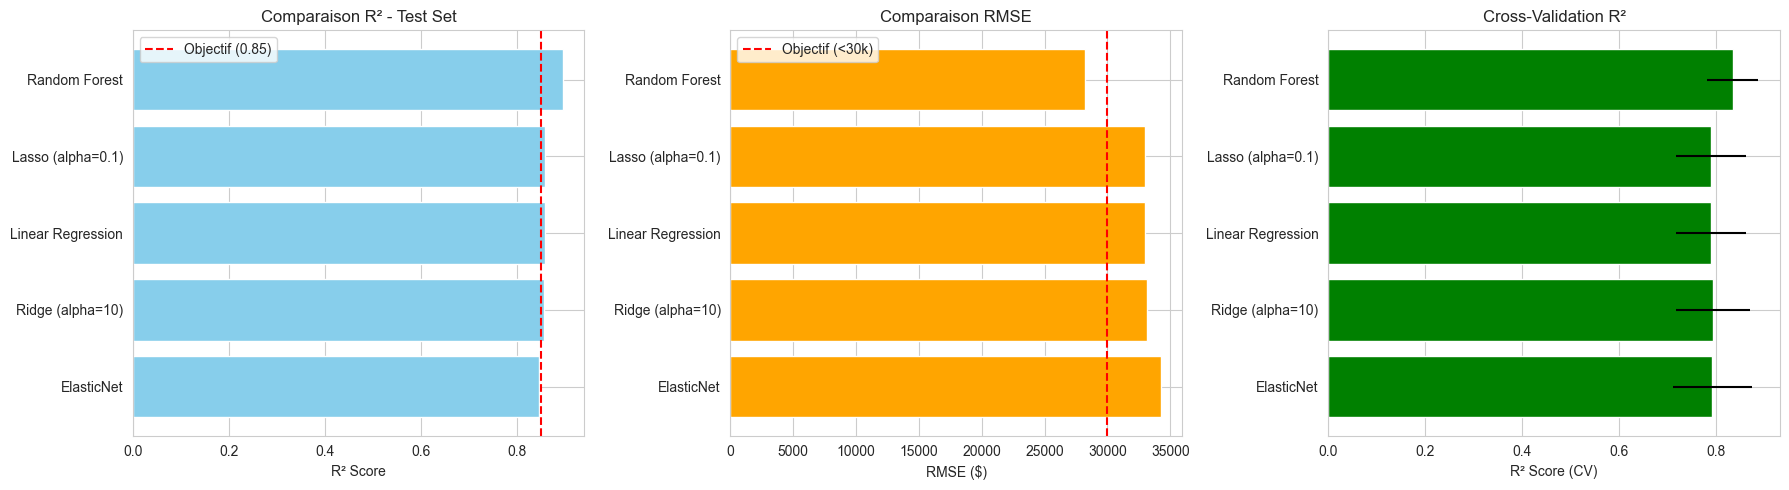

✅ images/predictions_vs_real.png


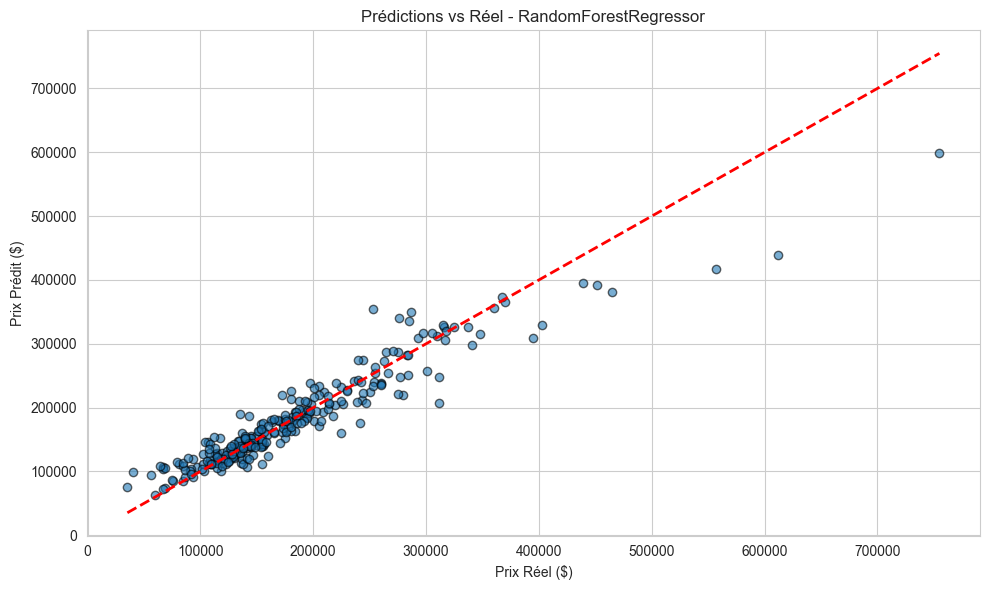

✅ images/residuals_analysis.png


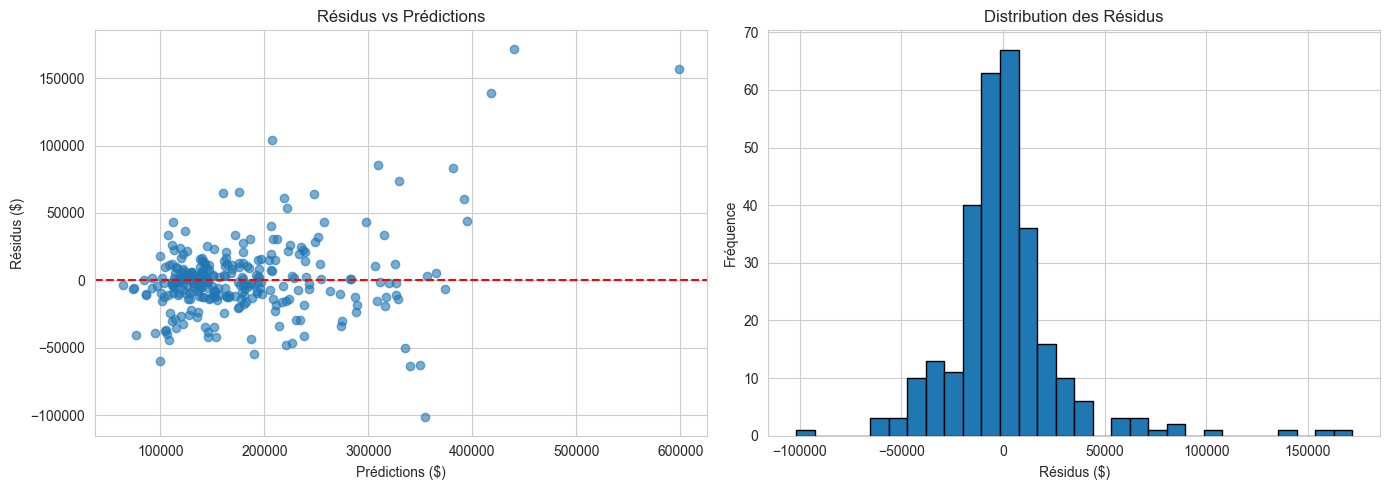


🔝 FEATURE IMPORTANCE - RANDOM FOREST

🔝 TOP 10 FEATURES :
             Feature  Importance
3   num__OverallQual    0.557404
15    num__GrLivArea    0.120471
11  num__TotalBsmtSF    0.035541
13     num__2ndFlrSF    0.035349
8    num__BsmtFinSF1    0.029922
12     num__1stFlrSF    0.025941
2       num__LotArea    0.016955
26   num__GarageArea    0.016499
25   num__GarageCars    0.012610
5     num__YearBuilt    0.011505

✅ images/feature_importance.png


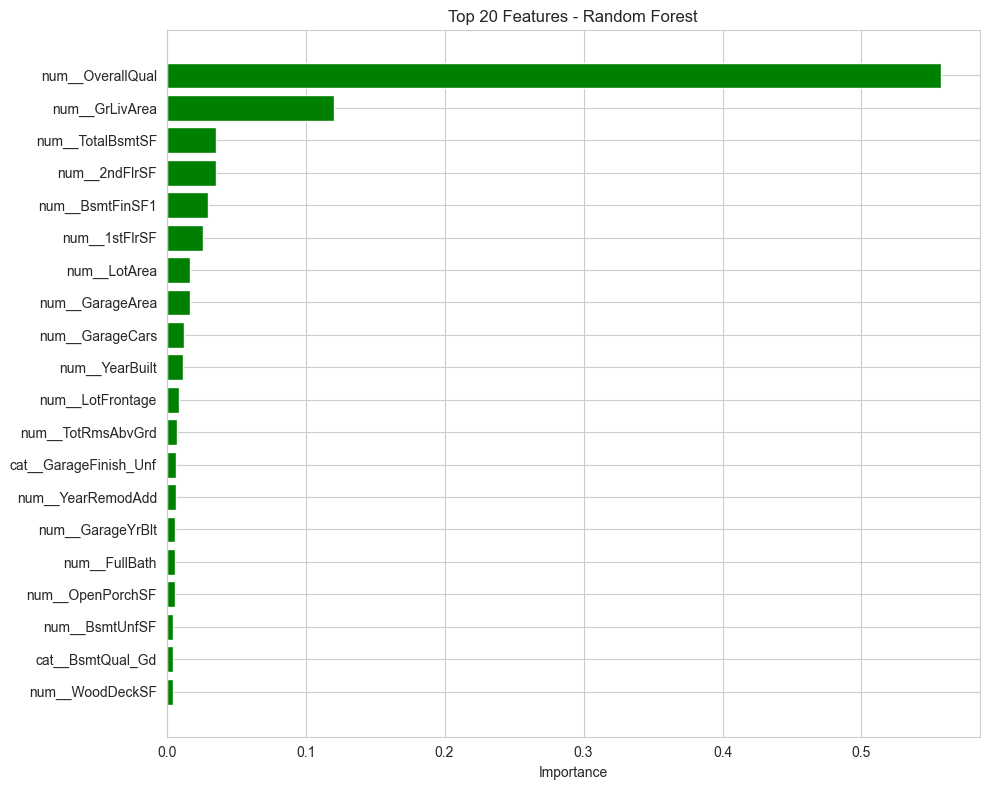


💾 SAUVEGARDE DU MODÈLE
✅ Modèle sauvegardé : models/best_model.pkl
✅ Résultats sauvegardés : models/model_comparison.csv

✅ ANALYSE TERMINÉE - RÉSUMÉ

🏆 MEILLEUR MODÈLE : RandomForestRegressor
   RMSE : $28,547
   R² : 0.8938

📊 OBJECTIFS CLIENT :
   ✅ R² > 0.85 : OUI (0.8938)
   ✅ RMSE < 30k : OUI ($28,547)

📁 FICHIERS GÉNÉRÉS :
   - images/model_comparison.png
   - images/predictions_vs_real.png
   - images/residuals_analysis.png
   - images/feature_importance.png
   - models/best_model.pkl
   - models/model_comparison.csv

🎉 PROJET TERMINÉ AVEC SUCCÈS !


In [ ]:
# Sépare X et y
X = df.drop(columns=['SalePrice', 'Id'])  # Enlève aussi Id (inutile)
y = df['SalePrice']

# Identifie colonnes numériques et catégorielles
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"📊 Variables numériques : {len(num_features)}")
print(f"📝 Variables catégorielles : {len(cat_features)}")

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n✂️ Split effectué :")
print(f"  Train : {X_train.shape[0]} lignes")
print(f"  Test : {X_test.shape[0]} lignes")

# ----------------------------
# 🧹 PREPROCESSING avec ColumnTransformer
# ----------------------------
print("\n" + "="*60)
print("🧹 CONSTRUCTION DU PREPROCESSOR")
print("="*60)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
        ]), cat_features)
    ]
)

print("✅ ColumnTransformer créé :")
print(f"  - Pipeline numérique : Imputer (median) + StandardScaler")
print(f"  - Pipeline catégoriel : Imputer (mode) + OneHotEncoder")

# ----------------------------
# 🤖 MODÈLE 1 : GridSearchCV pour trouver LE MEILLEUR
# ----------------------------
print("\n" + "="*60)
print("🤖 RECHERCHE DU MEILLEUR MODÈLE (GridSearchCV)")
print("="*60)

# Pipeline de base
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_regression, k=50)),
    ('model', LinearRegression())  # Placeholder
])

# Grille de paramètres multi-modèles
param_grid = [
    # Linear Regression
    {
        'model': [LinearRegression()],
        'feature_selection__k': [30, 50, 'all']
    },
    
    # Ridge
    {
        'model': [Ridge()],
        'model__alpha': [0.1, 1.0, 10.0, 50.0],
        'feature_selection__k': [30, 50]
    },
    
    # Lasso
    {
        'model': [Lasso(max_iter=10000)],
        'model__alpha': [0.001, 0.01, 0.1, 1.0],
        'feature_selection__k': [30, 50]
    },
    
    # ElasticNet
    {
        'model': [ElasticNet(max_iter=10000)],
        'model__alpha': [0.001, 0.01, 0.1],
        'model__l1_ratio': [0.2, 0.5, 0.8],
        'feature_selection__k': [30, 50]
    },
    
    # Random Forest
    {
        'model': [RandomForestRegressor(random_state=42)],
        'model__n_estimators': [100, 200],
        'model__max_depth': [10, 20, None],
        'feature_selection__k': [50, 'all']
    }
]

# GridSearchCV
print("🔍 GridSearchCV en cours (cela peut prendre quelques minutes)...")
grid = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1, 
    verbose=1
)

grid.fit(X_train, y_train)

# Meilleur modèle
best_model = grid.best_estimator_
print(f"\n✅ MEILLEUR MODÈLE TROUVÉ :")
print(f"  Modèle : {type(grid.best_estimator_['model']).__name__}")
print(f"  Paramètres : {grid.best_params_}")
print(f"  Score CV (R²) : {grid.best_score_:.4f}")

# Évaluation sur test
y_pred_best = best_model.predict(X_test)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"\n📊 PERFORMANCES SUR TEST :")
print(f"  RMSE : ${rmse_best:,.0f}")
print(f"  MAE : ${mae_best:,.0f}")
print(f"  R² : {r2_best:.4f}")

# ----------------------------
# 📊 COMPARAISON TOUS LES MODÈLES
# ----------------------------
print("\n" + "="*60)
print("📊 COMPARAISON DE TOUS LES MODÈLES")
print("="*60)

models_to_compare = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=10)': Ridge(alpha=10),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42)
}

results_comparison = {}

for name, model in models_to_compare.items():
    # Pipeline pour ce modèle
    pipeline_temp = Pipeline([
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=50)),
        ('model', model)
    ])
    
    # Entraîne
    pipeline_temp.fit(X_train, y_train)
    
    # Prédictions
    y_pred = pipeline_temp.predict(X_test)
    
    # Métriques
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(pipeline_temp, X_train, y_train, cv=5, scoring='r2')
    
    results_comparison[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'CV R² Mean': cv_scores.mean(),
        'CV R² Std': cv_scores.std()
    }
    
    print(f"\n{name}:")
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  MAE: ${mae:,.0f}")
    print(f"  R²: {r2:.4f}")
    print(f"  CV R²: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# ----------------------------
# 📈 TABLEAU RÉCAPITULATIF
# ----------------------------
results_df = pd.DataFrame(results_comparison).T.sort_values('R²', ascending=False)

print("\n" + "="*60)
print("📈 TABLEAU RÉCAPITULATIF")
print("="*60)
print(results_df)

# ----------------------------
# 📊 VISUALISATIONS
# ----------------------------
print("\n" + "="*60)
print(" GÉNÉRATION DES VISUALISATIONS")
print("="*60)

# Crée le dossier images si n'existe pas
import os
os.makedirs('images', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Figure 1 : Comparaison des modèles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R²
axes[0].barh(results_df.index, results_df['R²'], color='skyblue')
axes[0].set_xlabel('R² Score')
axes[0].set_title('Comparaison R² - Test Set')
axes[0].axvline(x=0.85, color='red', linestyle='--', label='Objectif (0.85)')
axes[0].legend()
axes[0].invert_yaxis()

# RMSE
axes[1].barh(results_df.index, results_df['RMSE'], color='orange')
axes[1].set_xlabel('RMSE ($)')
axes[1].set_title('Comparaison RMSE')
axes[1].axvline(x=30000, color='red', linestyle='--', label='Objectif (<30k)')
axes[1].legend()
axes[1].invert_yaxis()

# CV Scores
axes[2].barh(results_df.index, results_df['CV R² Mean'], xerr=results_df['CV R² Std'], color='green')
axes[2].set_xlabel('R² Score (CV)')
axes[2].set_title('Cross-Validation R²')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=300, bbox_inches='tight')
print("✅ images/model_comparison.png")
plt.show()

# Figure 2 : Prédictions vs Réel (meilleur modèle)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Prix Réel ($)')
plt.ylabel('Prix Prédit ($)')
plt.title(f'Prédictions vs Réel - {type(best_model["model"]).__name__}')
plt.tight_layout()
plt.savefig('images/predictions_vs_real.png', dpi=300, bbox_inches='tight')
print("✅ images/predictions_vs_real.png")
plt.show()

# Figure 3 : Résidus
residus = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Résidus vs Prédictions
axes[0].scatter(y_pred_best, residus, alpha=0.6)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Prédictions ($)')
axes[0].set_ylabel('Résidus ($)')
axes[0].set_title('Résidus vs Prédictions')

# Distribution des résidus
axes[1].hist(residus, bins=30, edgecolor='black')
axes[1].set_xlabel('Résidus ($)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des Résidus')

plt.tight_layout()
plt.savefig('images/residuals_analysis.png', dpi=300, bbox_inches='tight')
print("✅ images/residuals_analysis.png")
plt.show()

# ----------------------------
# 🔝 FEATURE IMPORTANCE (si Random Forest)
# ----------------------------
if 'RandomForest' in type(best_model['model']).__name__:
    print("\n" + "="*60)
    print(" FEATURE IMPORTANCE - RANDOM FOREST")
    print("="*60)
    
    # Récupère les noms des features après preprocessing
    preprocessed_features = best_model['preprocessor'].get_feature_names_out()
    
    # Récupère les features sélectionnées
    selected_idx = best_model['feature_selection'].get_support()
    selected_features = preprocessed_features[selected_idx]
    
    # Importance
    importances = best_model['model'].feature_importances_
    
    # DataFrame
    importance_df = pd.DataFrame({
        'Feature': selected_features,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("\n TOP 10 FEATURES :")
    print(importance_df.head(10))
    
    # Graphique
    plt.figure(figsize=(10, 8))
    top_20 = importance_df.head(20)
    plt.barh(top_20['Feature'], top_20['Importance'], color='green')
    plt.xlabel('Importance')
    plt.title('Top 20 Features - Random Forest')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('images/feature_importance.png', dpi=300, bbox_inches='tight')
    print("\n✅ images/feature_importance.png")
    plt.show()

# ----------------------------
# 💾 SAUVEGARDE DU MEILLEUR MODÈLE
# ----------------------------
print("\n" + "="*60)
print("💾 SAUVEGARDE DU MODÈLE")
print("="*60)

joblib.dump(best_model, 'models/best_model.pkl')
print("✅ Modèle sauvegardé : models/best_model.pkl")

# Sauvegarde aussi les résultats
results_df.to_csv('models/model_comparison.csv')
print("✅ Résultats sauvegardés : models/model_comparison.csv")

# ----------------------------
# ✅ RÉSUMÉ FINAL
# ----------------------------
print("\n" + "="*60)
print("✅ ANALYSE TERMINÉE - RÉSUMÉ")
print("="*60)

print(f"\n🏆 MEILLEUR MODÈLE : {type(best_model['model']).__name__}")
print(f"   RMSE : ${rmse_best:,.0f}")
print(f"   R² : {r2_best:.4f}")

print(f"\n📊 OBJECTIFS CLIENT :")
print(f"   ✅ R² > 0.85 : {'OUI' if r2_best > 0.85 else 'NON'} ({r2_best:.4f})")
print(f"   ✅ RMSE < 30k : {'OUI' if rmse_best < 30000 else 'NON'} (${rmse_best:,.0f})")



 TEST TRANSFORMATION LOG - MODÈLES LINÉAIRES

 Linear Regression

 SANS transformation :
   RMSE : $33,000
   MAE : $20,581
   R² : 0.8580
   CV R² : 0.7909 (±0.0723)

 AVEC transformation log :
   RMSE : $28,707
   MAE : $19,067
   R² : 0.8926
   CV R² (log) : 0.8338 (±0.0476)

 AMÉLIORATION :
   RMSE : +4,293$ (+13.0%)
   R² : +0.0345 (+4.0%)
    La transformation LOG AMÉLIORE Linear Regression !

 Ridge

 SANS transformation :
   RMSE : $33,137
   MAE : $20,457
   R² : 0.8568
   CV R² : 0.7948 (±0.0767)

 AVEC transformation log :
   RMSE : $28,858
   MAE : $19,034
   R² : 0.8914
   CV R² (log) : 0.8358 (±0.0505)

 AMÉLIORATION :
   RMSE : +4,279$ (+12.9%)
   R² : +0.0346 (+4.0%)
    La transformation LOG AMÉLIORE Ridge !

 Lasso

 SANS transformation :
   RMSE : $32,998
   MAE : $20,581
   R² : 0.8580
   CV R² : 0.7909 (±0.0723)

 AVEC transformation log :
   RMSE : $52,362
   MAE : $31,320
   R² : 0.6425
   CV R² (log) : 0.6762 (±0.0257)

 AMÉLIORATION :
   RMSE : -19,364$ (-58.7%

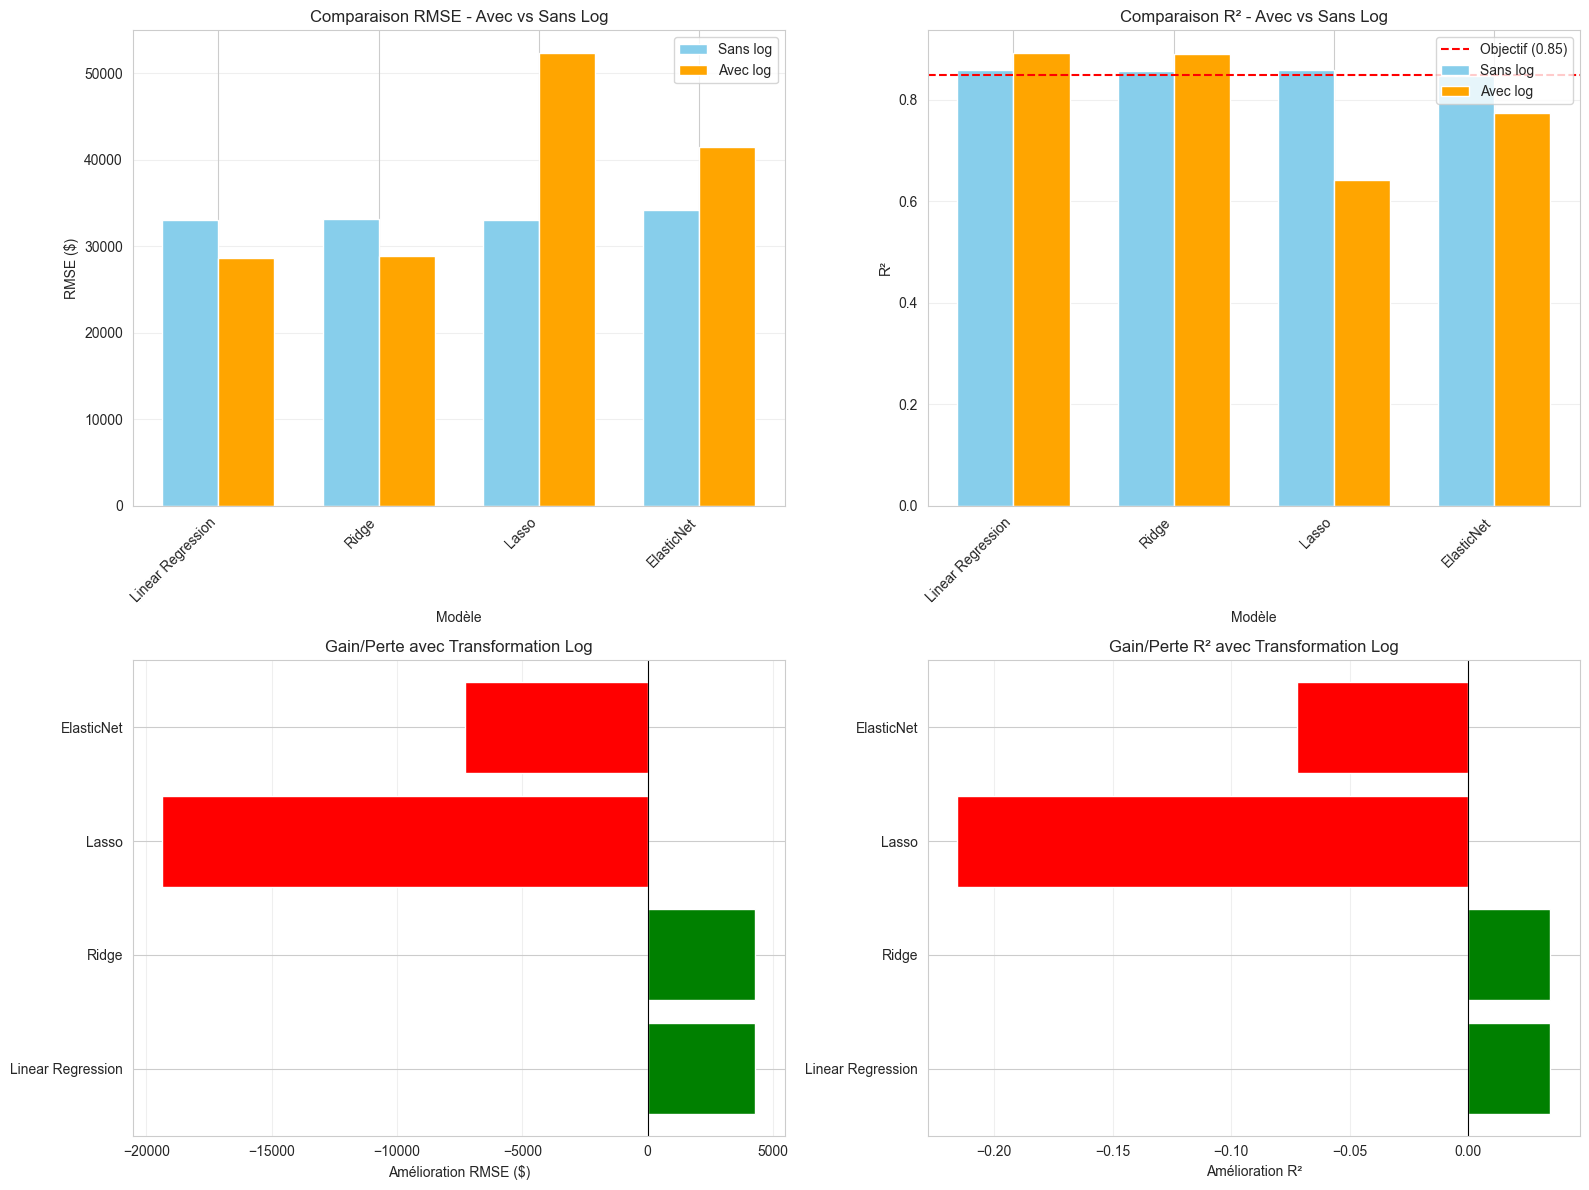


 CONCLUSION

2/4 modèles linéaires s'améliorent avec la transformation log

 RECOMMANDATION : Utilise la transformation log pour les modèles linéaires

 MEILLEUR MODÈLE LINÉAIRE (avec log) :
   Linear Regression
   RMSE : $28,707
   R² : 0.8926

 RAPPEL - Random Forest (sans log) :
   RMSE : $28,547
   R² : 0.8938

Random Forest reste probablement le meilleur modèle global !


In [29]:
#
print("="*60)
print(" TEST TRANSFORMATION LOG - MODÈLES LINÉAIRES")
print("="*60)

# ----------------------------
# 1️⃣ PRÉPARE LES DONNÉES
# ----------------------------

# Target originale
y_train_original = y_train.copy()
y_test_original = y_test.copy()

# Target transformée (log)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)



# ----------------------------
#  MODÈLES À TESTER
# ----------------------------


models_to_test = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=10),
    'Lasso': Lasso(alpha=0.1, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
}



results_comparison = {}

for model_name, model in models_to_test.items():
    print(f"\n{'='*60}")
    print(f" {model_name}")
    print(f"{'='*60}")
    
    pipeline_original = Pipeline([
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=50)),
        ('model', model)
    ])
    
    # Entraîne
    pipeline_original.fit(X_train, y_train_original)
    
    # Prédictions
    y_pred_original = pipeline_original.predict(X_test)
    
    # Métriques
    rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    mae_original = mean_absolute_error(y_test_original, y_pred_original)
    r2_original = r2_score(y_test_original, y_pred_original)
    
    # Cross-validation
    cv_scores_original = cross_val_score(
        pipeline_original, X_train, y_train_original, 
        cv=5, scoring='r2'
    )
    
    print(f"\n SANS transformation :")
    print(f"   RMSE : ${rmse_original:,.0f}")
    print(f"   MAE : ${mae_original:,.0f}")
    print(f"   R² : {r2_original:.4f}")
    print(f"   CV R² : {cv_scores_original.mean():.4f} (±{cv_scores_original.std():.4f})")
    
    # ----- AVEC TRANSFORMATION LOG -----
    pipeline_log = Pipeline([
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=50)),
        ('model', model)
    ])
    
    # Entraîne sur target LOG
    pipeline_log.fit(X_train, y_train_log)
    
    # Prédictions en LOG
    y_pred_log = pipeline_log.predict(X_test)
    
    # RETRANSFORME en prix réels
    y_pred_exp = np.expm1(y_pred_log)
    
    # Métriques (sur prix réels)
    rmse_log = np.sqrt(mean_squared_error(y_test_original, y_pred_exp))
    mae_log = mean_absolute_error(y_test_original, y_pred_exp)
    r2_log = r2_score(y_test_original, y_pred_exp)
    
    # Cross-validation (sur log, puis retransformé)
    cv_scores_log = cross_val_score(
        pipeline_log, X_train, y_train_log, 
        cv=5, scoring='r2'
    )
    
    print(f"\n AVEC transformation log :")
    print(f"   RMSE : ${rmse_log:,.0f}")
    print(f"   MAE : ${mae_log:,.0f}")
    print(f"   R² : {r2_log:.4f}")
    print(f"   CV R² (log) : {cv_scores_log.mean():.4f} (±{cv_scores_log.std():.4f})")
    
    # ----- AMÉLIORATION -----
    diff_rmse = rmse_original - rmse_log
    diff_r2 = r2_log - r2_original
    
    print(f"\n AMÉLIORATION :")
    print(f"   RMSE : {diff_rmse:+,.0f}$ ({diff_rmse/rmse_original*100:+.1f}%)")
    print(f"   R² : {diff_r2:+.4f} ({diff_r2/abs(r2_original)*100:+.1f}%)")
    
    if rmse_log < rmse_original:
        print(f"    La transformation LOG AMÉLIORE {model_name} !")
    else:
        print(f"    La transformation LOG n'améliore PAS {model_name}")
    
    # Stocke résultats
    results_comparison[model_name] = {
        'RMSE (original)': rmse_original,
        'RMSE (log)': rmse_log,
        'R² (original)': r2_original,
        'R² (log)': r2_log,
        'Amélioration RMSE': diff_rmse,
        'Amélioration R²': diff_r2
    }

# ----------------------------
#  TABLEAU RÉCAPITULATIF
# ----------------------------

print("\n" + "="*60)
print(" TABLEAU RÉCAPITULATIF")
print("="*60)

results_df = pd.DataFrame(results_comparison).T
print("\n", results_df)

# Meilleurs modèles
print("\n MEILLEURS MODÈLES :")
print("\nSANS transformation :")
best_original = results_df['R² (original)'].idxmax()
print(f"  {best_original} : R²={results_df.loc[best_original, 'R² (original)']:.4f}")

print("\nAVEC transformation log :")
best_log = results_df['R² (log)'].idxmax()
print(f"  {best_log} : R²={results_df.loc[best_log, 'R² (log)']:.4f}")

# ----------------------------
# 5️⃣ VISUALISATIONS
# ----------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graphique 1 : Comparaison RMSE
ax1 = axes[0, 0]
x_pos = np.arange(len(results_df))
width = 0.35
ax1.bar(x_pos - width/2, results_df['RMSE (original)'], width, label='Sans log', color='skyblue')
ax1.bar(x_pos + width/2, results_df['RMSE (log)'], width, label='Avec log', color='orange')
ax1.set_xlabel('Modèle')
ax1.set_ylabel('RMSE ($)')
ax1.set_title('Comparaison RMSE - Avec vs Sans Log')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df.index, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Graphique 2 : Comparaison R²
ax2 = axes[0, 1]
ax2.bar(x_pos - width/2, results_df['R² (original)'], width, label='Sans log', color='skyblue')
ax2.bar(x_pos + width/2, results_df['R² (log)'], width, label='Avec log', color='orange')
ax2.set_xlabel('Modèle')
ax2.set_ylabel('R²')
ax2.set_title('Comparaison R² - Avec vs Sans Log')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(results_df.index, rotation=45, ha='right')
ax2.axhline(y=0.85, color='red', linestyle='--', label='Objectif (0.85)')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Graphique 3 : Amélioration RMSE
ax3 = axes[1, 0]
colors = ['green' if x > 0 else 'red' for x in results_df['Amélioration RMSE']]
ax3.barh(results_df.index, results_df['Amélioration RMSE'], color=colors)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax3.set_xlabel('Amélioration RMSE ($)')
ax3.set_title('Gain/Perte avec Transformation Log')
ax3.grid(axis='x', alpha=0.3)

# Graphique 4 : Amélioration R²
ax4 = axes[1, 1]
colors = ['green' if x > 0 else 'red' for x in results_df['Amélioration R²']]
ax4.barh(results_df.index, results_df['Amélioration R²'], color=colors)
ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax4.set_xlabel('Amélioration R²')
ax4.set_title('Gain/Perte R² avec Transformation Log')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('images/log_transform_linear_models.png', dpi=300, bbox_inches='tight')
print("\n Graphique sauvegardé : images/log_transform_linear_models.png")
plt.show()

# ----------------------------
#  CONCLUSION FINALE
# ----------------------------

print("\n" + "="*60)
print(" CONCLUSION")
print("="*60)

# Compte combien de modèles s'améliorent
improvements = (results_df['Amélioration R²'] > 0).sum()
total = len(results_df)

print(f"\n{improvements}/{total} modèles linéaires s'améliorent avec la transformation log")

if improvements >= total / 2:
    print("\n RECOMMANDATION : Utilise la transformation log pour les modèles linéaires")
    best_linear_model = results_df['R² (log)'].idxmax()
    best_r2 = results_df.loc[best_linear_model, 'R² (log)']
    best_rmse = results_df.loc[best_linear_model, 'RMSE (log)']
    print(f"\n MEILLEUR MODÈLE LINÉAIRE (avec log) :")
    print(f"   {best_linear_model}")
    print(f"   RMSE : ${best_rmse:,.0f}")
    print(f"   R² : {best_r2:.4f}")
else:
    print("\n RECOMMANDATION : La transformation log n'aide pas significativement")

# Compare avec Random Forest
print(f"\n RAPPEL - Random Forest (sans log) :")
print(f"   RMSE : $28,547")
print(f"   R² : 0.8938")

print("\nRandom Forest reste probablement le meilleur modèle global !")

 ANALYSE DES OUTLIERS

 MÉTHODE IQR (sur SalePrice) :
   Q1 (25%) : $130,000
   Q3 (75%) : $214,925
   IQR : $84,925
   Borne inférieure : $2,612
   Borne supérieure : $342,312
   Outliers détectés : 48 (4.1%)


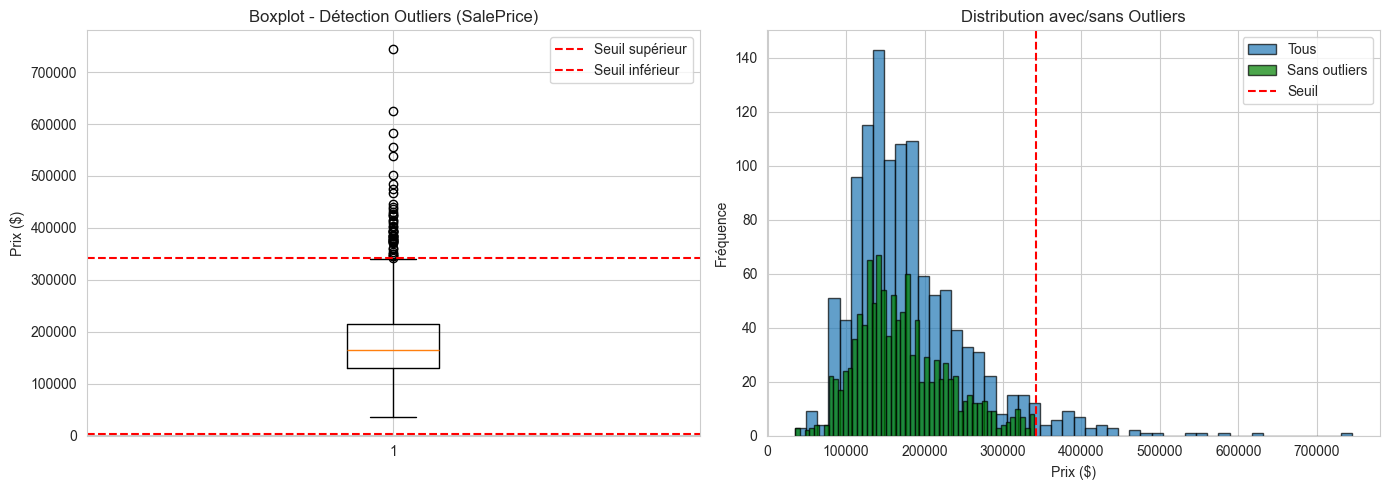


 MÉTHODE ISOLATION FOREST (multivariée) :
   Outliers détectés : 59 (5.1%)

 DATASETS CRÉÉS :
   Dataset COMPLET : 1168 lignes
   Dataset SANS outliers (IQR) : 1120 lignes
   Lignes supprimées : 48

 COMPARAISON AVEC/SANS OUTLIERS

 Linear Regression

 AVEC outliers :
   RMSE : $33,000
   MAE : $20,581
   R² : 0.8580

 SANS outliers :
   RMSE : $41,626
   MAE : $22,890
   R² : 0.7741

 AMÉLIORATION :
   RMSE : -8,626$ (-26.1%)
   R² : -0.0839 (-9.8%)
    Supprimer les outliers N'AMÉLIORE PAS Linear Regression

 Ridge

 AVEC outliers :
   RMSE : $33,137
   MAE : $20,457
   R² : 0.8568

 SANS outliers :
   RMSE : $42,033
   MAE : $23,018
   R² : 0.7697

 AMÉLIORATION :
   RMSE : -8,896$ (-26.8%)
   R² : -0.0872 (-10.2%)
    Supprimer les outliers N'AMÉLIORE PAS Ridge

 Lasso

 AVEC outliers :
   RMSE : $32,998
   MAE : $20,581
   R² : 0.8580

 SANS outliers :
   RMSE : $41,625
   MAE : $22,889
   R² : 0.7741

 AMÉLIORATION :
   RMSE : -8,628$ (-26.1%)
   R² : -0.0839 (-9.8%)
    Supprim

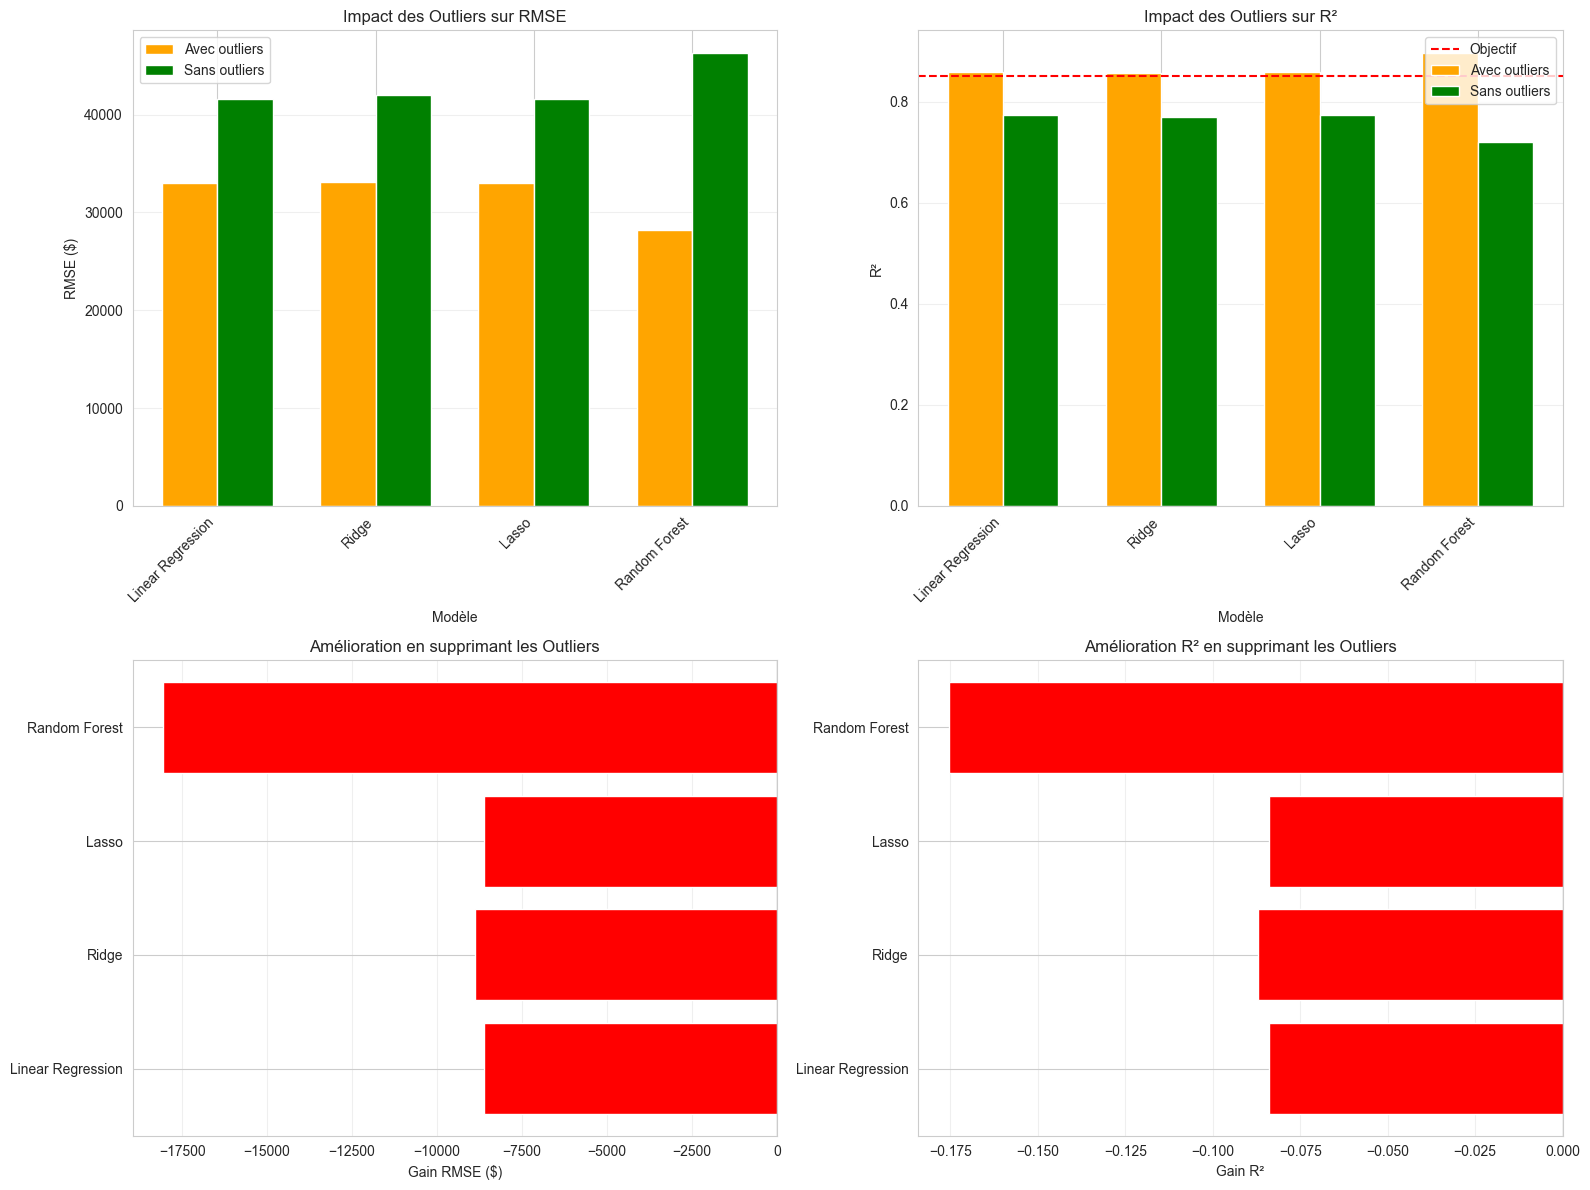


 CONCLUSION - IMPACT DES OUTLIERS

 0/4 modèles s'améliorent en supprimant les outliers

 RECOMMANDATION : Garder les outliers
Les outliers contiennent de l'information utile pour la prédiction


In [30]:


print("="*60)
print(" ANALYSE DES OUTLIERS")
print("="*60)

# ----------------------------
#  DÉTECTION DES OUTLIERS (MÉTHODE IQR)
# ----------------------------

# Sur la target (SalePrice)
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identifie les outliers
outliers_mask = (y_train < lower_bound) | (y_train > upper_bound)
n_outliers = outliers_mask.sum()

print(f"\n MÉTHODE IQR (sur SalePrice) :")
print(f"   Q1 (25%) : ${Q1:,.0f}")
print(f"   Q3 (75%) : ${Q3:,.0f}")
print(f"   IQR : ${IQR:,.0f}")
print(f"   Borne inférieure : ${lower_bound:,.0f}")
print(f"   Borne supérieure : ${upper_bound:,.0f}")
print(f"   Outliers détectés : {n_outliers} ({n_outliers/len(y_train)*100:.1f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(y_train)
axes[0].set_ylabel('Prix ($)')
axes[0].set_title('Boxplot - Détection Outliers (SalePrice)')
axes[0].axhline(y=upper_bound, color='r', linestyle='--', label='Seuil supérieur')
axes[0].axhline(y=lower_bound, color='r', linestyle='--', label='Seuil inférieur')
axes[0].legend()

# Distribution
axes[1].hist(y_train, bins=50, edgecolor='black', alpha=0.7, label='Tous')
axes[1].hist(y_train[~outliers_mask], bins=50, edgecolor='black', alpha=0.7, label='Sans outliers', color='green')
axes[1].axvline(x=upper_bound, color='r', linestyle='--', label='Seuil')
axes[1].set_xlabel('Prix ($)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution avec/sans Outliers')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/outliers_detection.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------
#  MÉTHODE ISOLATION FOREST (multivariée)
# ----------------------------

print(f"\n MÉTHODE ISOLATION FOREST (multivariée) :")

# Prépare les données pour Isolation Forest
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Convertit en dense si sparse
if hasattr(X_train_preprocessed, 'toarray'):
    X_train_dense = X_train_preprocessed.toarray()
else:
    X_train_dense = X_train_preprocessed

# Isolation Forest
iso_forest = IsolationForest(
    contamination=0.05,  # 5% d'outliers attendus
    random_state=42,
    n_estimators=100
)

outliers_iso = iso_forest.fit_predict(X_train_dense)
n_outliers_iso = (outliers_iso == -1).sum()

print(f"   Outliers détectés : {n_outliers_iso} ({n_outliers_iso/len(X_train)*100:.1f}%)")

# ----------------------------
#  CRÉE LES DATASETS AVEC/SANS OUTLIERS
# ----------------------------

# Méthode IQR (sur target uniquement)
X_train_no_outliers_iqr = X_train[~outliers_mask]
y_train_no_outliers_iqr = y_train[~outliers_mask]

print(f"\n DATASETS CRÉÉS :")
print(f"   Dataset COMPLET : {len(X_train)} lignes")
print(f"   Dataset SANS outliers (IQR) : {len(X_train_no_outliers_iqr)} lignes")
print(f"   Lignes supprimées : {len(X_train) - len(X_train_no_outliers_iqr)}")

# ----------------------------
# 4 ENTRAÎNE ET COMPARE LES MODÈLES
# ----------------------------

print("\n" + "="*60)
print(" COMPARAISON AVEC/SANS OUTLIERS")
print("="*60)

# Modèles à tester
models_to_compare = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=10),
    'Lasso': Lasso(alpha=0.1, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42)
}

results_outliers = {}

for model_name, model in models_to_compare.items():
    print(f"\n{'='*60}")
    print(f" {model_name}")
    print(f"{'='*60}")
    
    # ----- AVEC OUTLIERS -----
    pipeline_with = Pipeline([
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=50)),
        ('model', model)
    ])
    
    pipeline_with.fit(X_train, y_train)
    y_pred_with = pipeline_with.predict(X_test)
    
    rmse_with = np.sqrt(mean_squared_error(y_test, y_pred_with))
    mae_with = mean_absolute_error(y_test, y_pred_with)
    r2_with = r2_score(y_test, y_pred_with)
    
    print(f"\n AVEC outliers :")
    print(f"   RMSE : ${rmse_with:,.0f}")
    print(f"   MAE : ${mae_with:,.0f}")
    print(f"   R² : {r2_with:.4f}")
    
    # ----- SANS OUTLIERS -----
    pipeline_without = Pipeline([
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=50)),
        ('model', model)
    ])
    
    pipeline_without.fit(X_train_no_outliers_iqr, y_train_no_outliers_iqr)
    y_pred_without = pipeline_without.predict(X_test)
    
    rmse_without = np.sqrt(mean_squared_error(y_test, y_pred_without))
    mae_without = mean_absolute_error(y_test, y_pred_without)
    r2_without = r2_score(y_test, y_pred_without)
    
    print(f"\n SANS outliers :")
    print(f"   RMSE : ${rmse_without:,.0f}")
    print(f"   MAE : ${mae_without:,.0f}")
    print(f"   R² : {r2_without:.4f}")
    
    # ----- AMÉLIORATION -----
    diff_rmse = rmse_with - rmse_without
    diff_r2 = r2_without - r2_with
    
    print(f"\n AMÉLIORATION :")
    print(f"   RMSE : {diff_rmse:+,.0f}$ ({diff_rmse/rmse_with*100:+.1f}%)")
    print(f"   R² : {diff_r2:+.4f} ({diff_r2/abs(r2_with)*100:+.1f}%)")
    
    if rmse_without < rmse_with:
        print(f"    Supprimer les outliers AMÉLIORE {model_name}")
    else:
        print(f"    Supprimer les outliers N'AMÉLIORE PAS {model_name}")
    
    # Stocke résultats
    results_outliers[model_name] = {
        'RMSE (avec)': rmse_with,
        'RMSE (sans)': rmse_without,
        'R² (avec)': r2_with,
        'R² (sans)': r2_without,
        'Gain RMSE': diff_rmse,
        'Gain R²': diff_r2
    }

# ----------------------------
# 5️⃣ TABLEAU RÉCAPITULATIF
# ----------------------------

print("\n" + "="*60)
print("TABLEAU RÉCAPITULATIF")
print("="*60)

results_df = pd.DataFrame(results_outliers).T
print("\n", results_df)

# ----------------------------
# 6️⃣ VISUALISATIONS
# ----------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graphique 1 : Comparaison RMSE
ax1 = axes[0, 0]
x_pos = np.arange(len(results_df))
width = 0.35
ax1.bar(x_pos - width/2, results_df['RMSE (avec)'], width, label='Avec outliers', color='orange')
ax1.bar(x_pos + width/2, results_df['RMSE (sans)'], width, label='Sans outliers', color='green')
ax1.set_xlabel('Modèle')
ax1.set_ylabel('RMSE ($)')
ax1.set_title('Impact des Outliers sur RMSE')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df.index, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Graphique 2 : Comparaison R²
ax2 = axes[0, 1]
ax2.bar(x_pos - width/2, results_df['R² (avec)'], width, label='Avec outliers', color='orange')
ax2.bar(x_pos + width/2, results_df['R² (sans)'], width, label='Sans outliers', color='green')
ax2.set_xlabel('Modèle')
ax2.set_ylabel('R²')
ax2.set_title('Impact des Outliers sur R²')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(results_df.index, rotation=45, ha='right')
ax2.axhline(y=0.85, color='red', linestyle='--', label='Objectif')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Graphique 3 : Gain RMSE
ax3 = axes[1, 0]
colors = ['green' if x > 0 else 'red' for x in results_df['Gain RMSE']]
ax3.barh(results_df.index, results_df['Gain RMSE'], color=colors)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax3.set_xlabel('Gain RMSE ($)')
ax3.set_title('Amélioration en supprimant les Outliers')
ax3.grid(axis='x', alpha=0.3)

# Graphique 4 : Gain R²
ax4 = axes[1, 1]
colors = ['green' if x > 0 else 'red' for x in results_df['Gain R²']]
ax4.barh(results_df.index, results_df['Gain R²'], color=colors)
ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax4.set_xlabel('Gain R²')
ax4.set_title('Amélioration R² en supprimant les Outliers')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('images/outliers_impact_comparison.png', dpi=300, bbox_inches='tight')
print("\n✅ Graphique sauvegardé : images/outliers_impact_comparison.png")
plt.show()

# ----------------------------
#  CONCLUSION
# ----------------------------

print("\n" + "="*60)
print(" CONCLUSION - IMPACT DES OUTLIERS")
print("="*60)

improvements = (results_df['Gain R²'] > 0).sum()
total = len(results_df)

print(f"\n {improvements}/{total} modèles s'améliorent en supprimant les outliers")

if improvements >= total / 2:
    print("\n RECOMMANDATION : Supprimer les outliers améliore les performances")
    best_model_name = results_df['R² (sans)'].idxmax()
    best_r2 = results_df.loc[best_model_name, 'R² (sans)']
    best_rmse = results_df.loc[best_model_name, 'RMSE (sans)']
    print(f"\n🏆 MEILLEUR MODÈLE (sans outliers) :")
    print(f"   {best_model_name}")
    print(f"   RMSE : ${best_rmse:,.0f}")
    print(f"   R² : {best_r2:.4f}")
else:
    print("\n RECOMMANDATION : Garder les outliers")
    print("Les outliers contiennent de l'information utile pour la prédiction")


🔍 INTERPRÉTABILITÉ DU MODÈLE RANDOM FOREST

📊 FEATURE IMPORTANCE (Méthode native)
✅ Nombre de features après preprocessing : 242
✅ Nombre de features sélectionnées : 50
✅ Nombre d'importances : 50

🔝 TOP 20 FEATURES LES PLUS IMPORTANTES :
                  Feature  Importance
2        num__OverallQual    0.558151
10         num__GrLivArea    0.126699
7        num__TotalBsmtSF    0.036523
9           num__2ndFlrSF    0.033120
6         num__BsmtFinSF1    0.033010
8           num__1stFlrSF    0.031111
1            num__LotArea    0.022133
17        num__GarageArea    0.017870
16        num__GarageCars    0.015412
3          num__YearBuilt    0.014116
0        num__LotFrontage    0.011437
4       num__YearRemodAdd    0.009166
19       num__OpenPorchSF    0.007931
15       num__GarageYrBlt    0.007879
13      num__TotRmsAbvGrd    0.007391
11          num__FullBath    0.006987
46  cat__GarageFinish_Unf    0.006253
18        num__WoodDeckSF    0.006052
34       cat__BsmtQual_Gd    0.005490


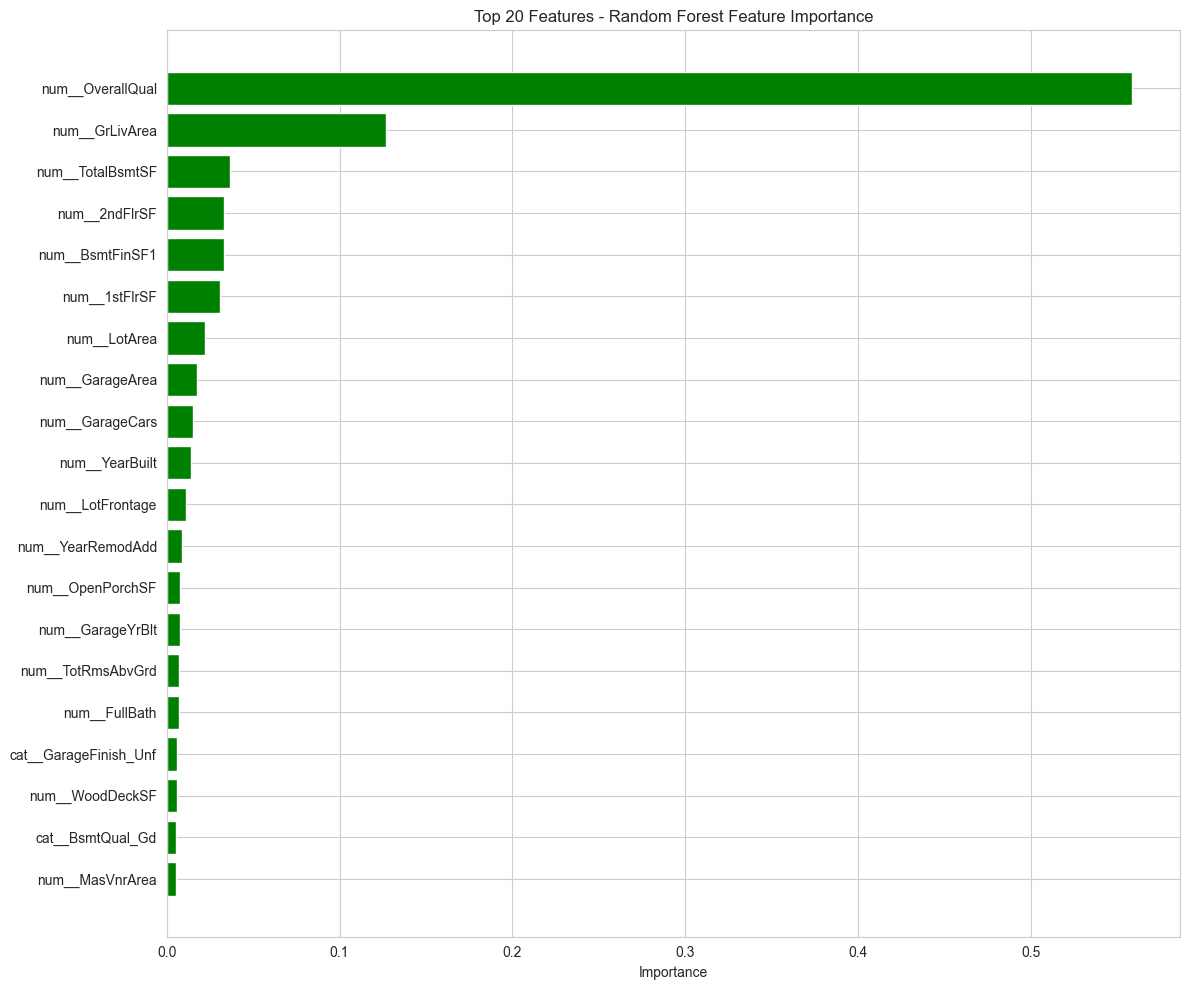


📊 PERMUTATION IMPORTANCE (Méthode avancée)
✅ X_test après preprocessing : (292, 242)
✅ X_test après sélection : (292, 50)
⏳ Calcul permutation importance (peut prendre 30s-1min)...

🔝 TOP 20 FEATURES (Permutation) :
                 Feature  Importance       Std
2       num__OverallQual    0.480138  0.030687
10        num__GrLivArea    0.113781  0.008175
9          num__2ndFlrSF    0.030596  0.003212
7       num__TotalBsmtSF    0.022259  0.002742
8          num__1stFlrSF    0.019753  0.003546
16       num__GarageCars    0.018962  0.001891
6        num__BsmtFinSF1    0.017592  0.003349
1           num__LotArea    0.012710  0.002286
17       num__GarageArea    0.005924  0.001630
3         num__YearBuilt    0.005193  0.000937
4      num__YearRemodAdd    0.004057  0.001023
13     num__TotRmsAbvGrd    0.003685  0.000622
15      num__GarageYrBlt    0.003483  0.000780
34      cat__BsmtQual_Gd    0.002601  0.000636
36  cat__BsmtExposure_Gd    0.002255  0.000284
42   cat__KitchenQual_Gd    0.0

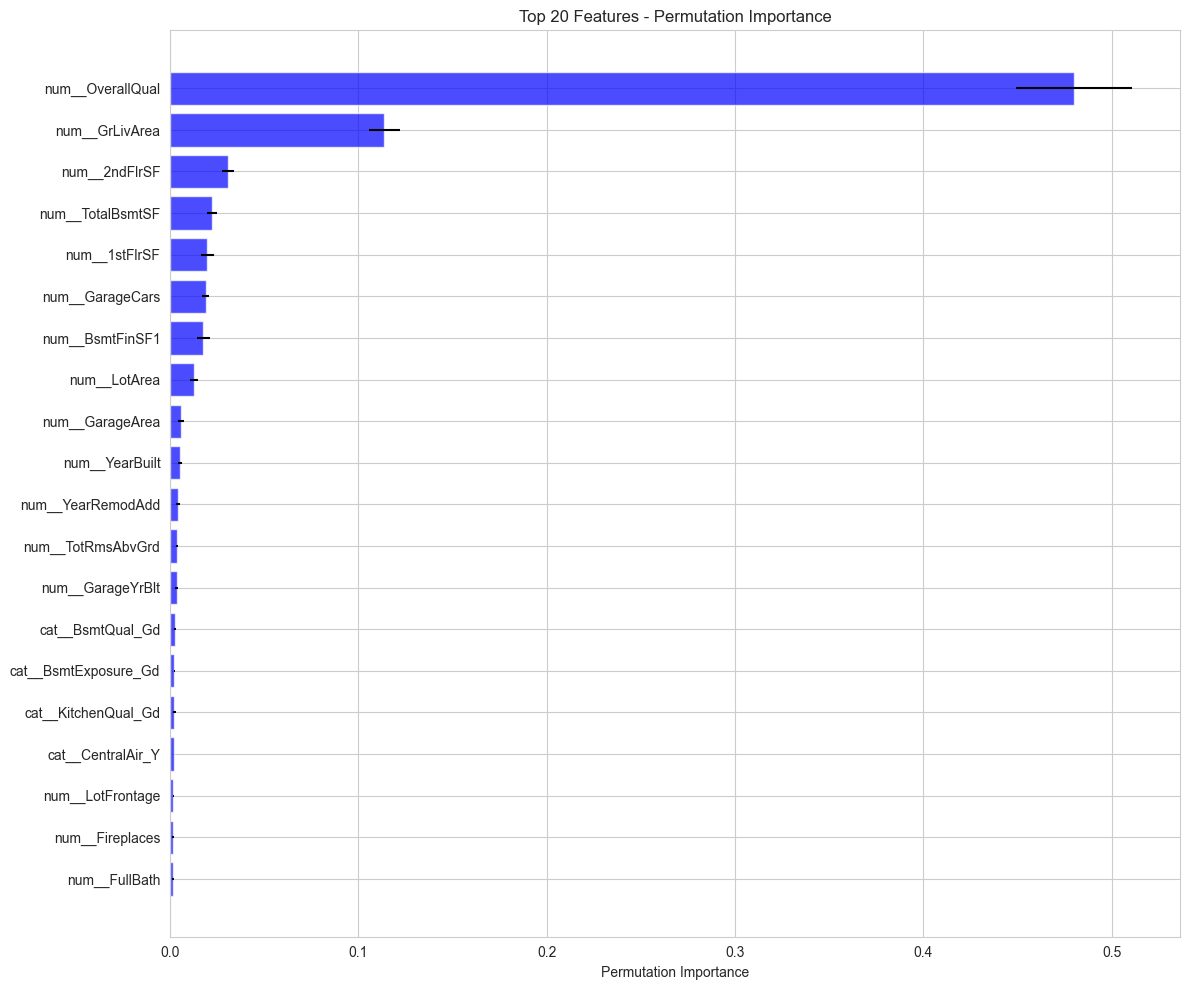


📊 SHAP VALUES (Explainability avancée)
✅ Données SHAP : (292, 50)
⏳ Calcul des SHAP values (peut prendre 1-3 minutes)...
✅ SHAP values shape : (292, 50)
✅ images/shap_summary_plot.png


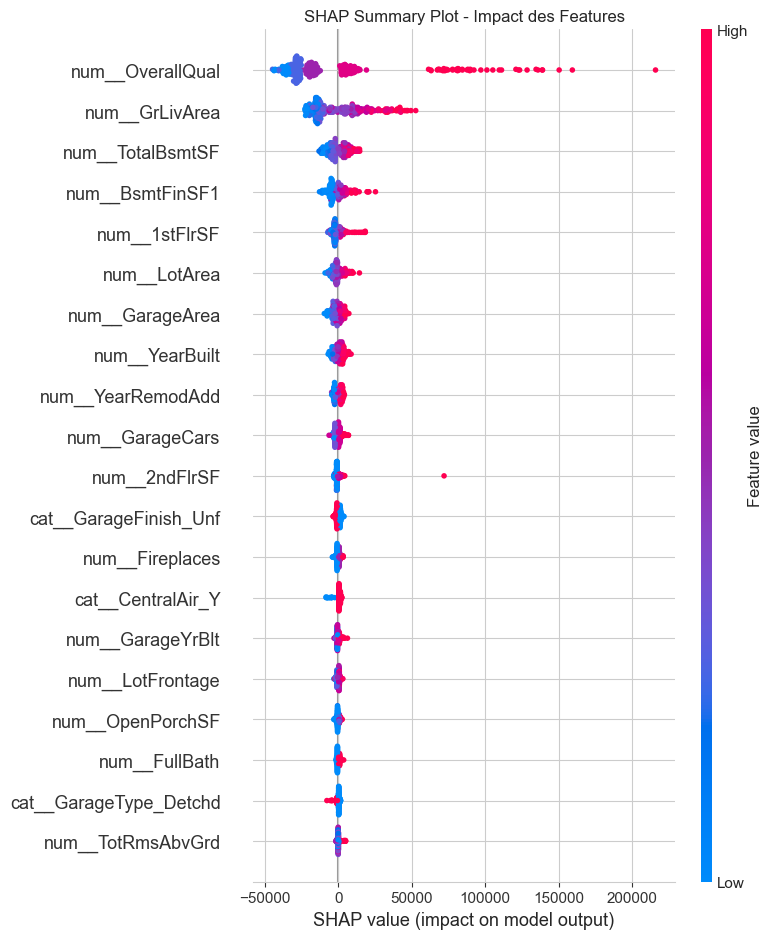

✅ images/shap_importance_bar.png


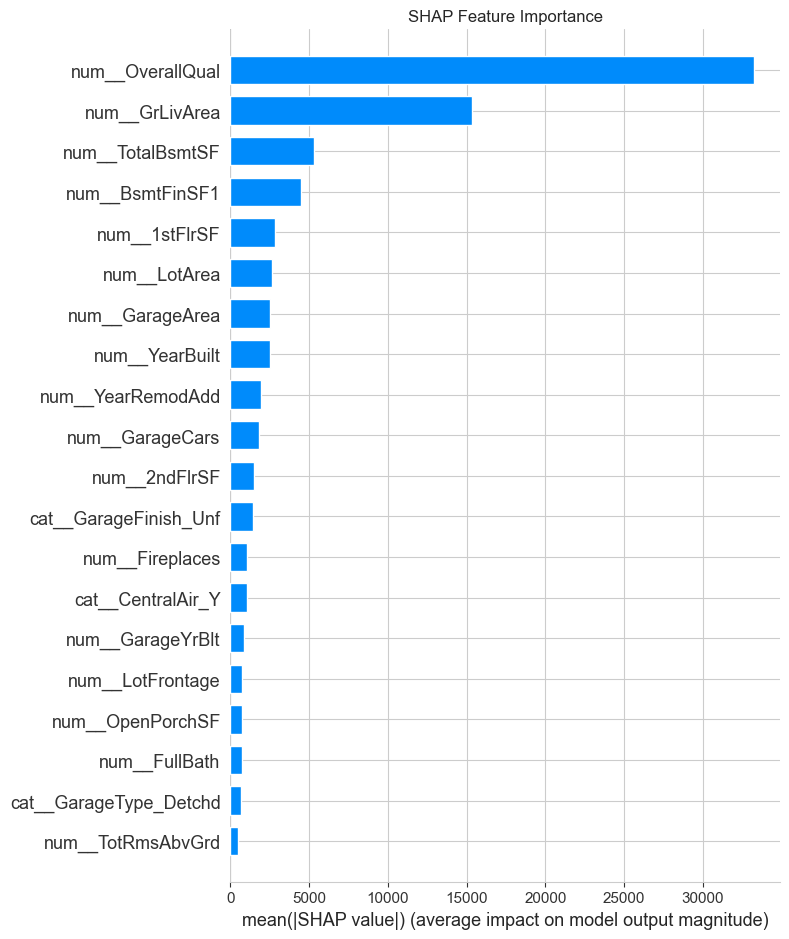

✅ images/shap_dependence_plots.png


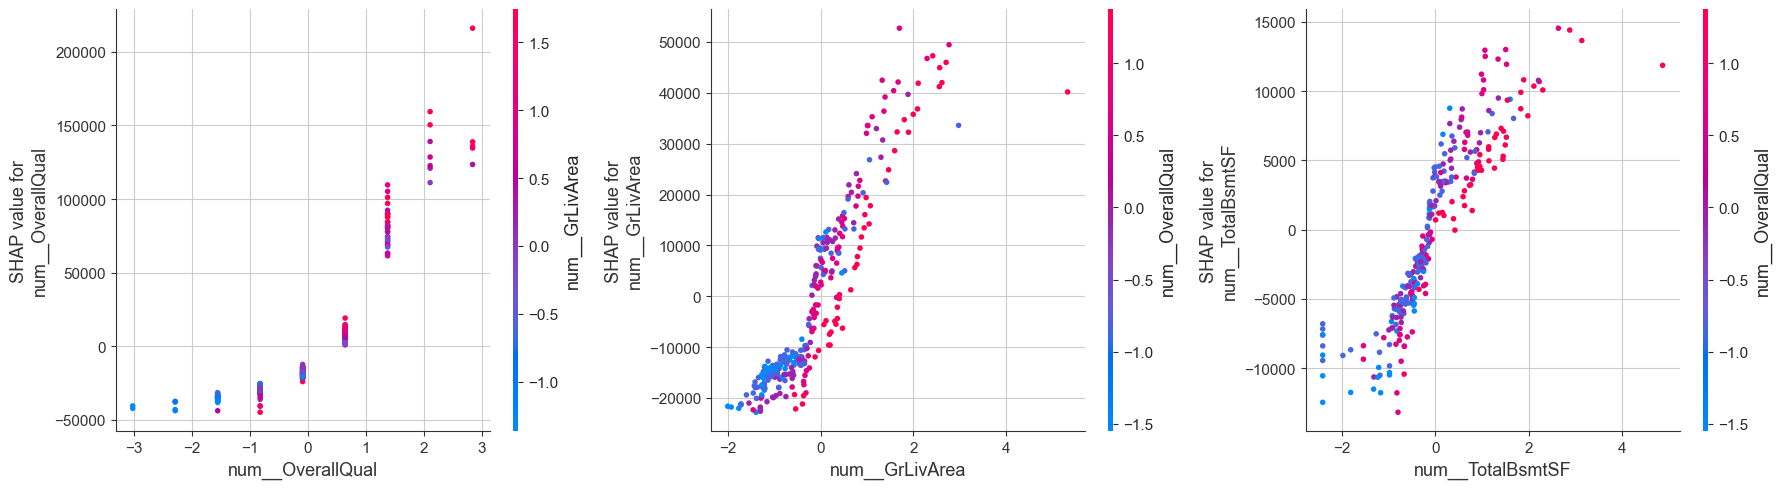

✅ SHAP values calculées avec succès !

📊 PARTIAL DEPENDENCE PLOTS
Top 4 features : ['num__OverallQual', 'num__GrLivArea', 'num__TotalBsmtSF', 'num__2ndFlrSF']
✅ images/partial_dependence_plots.png


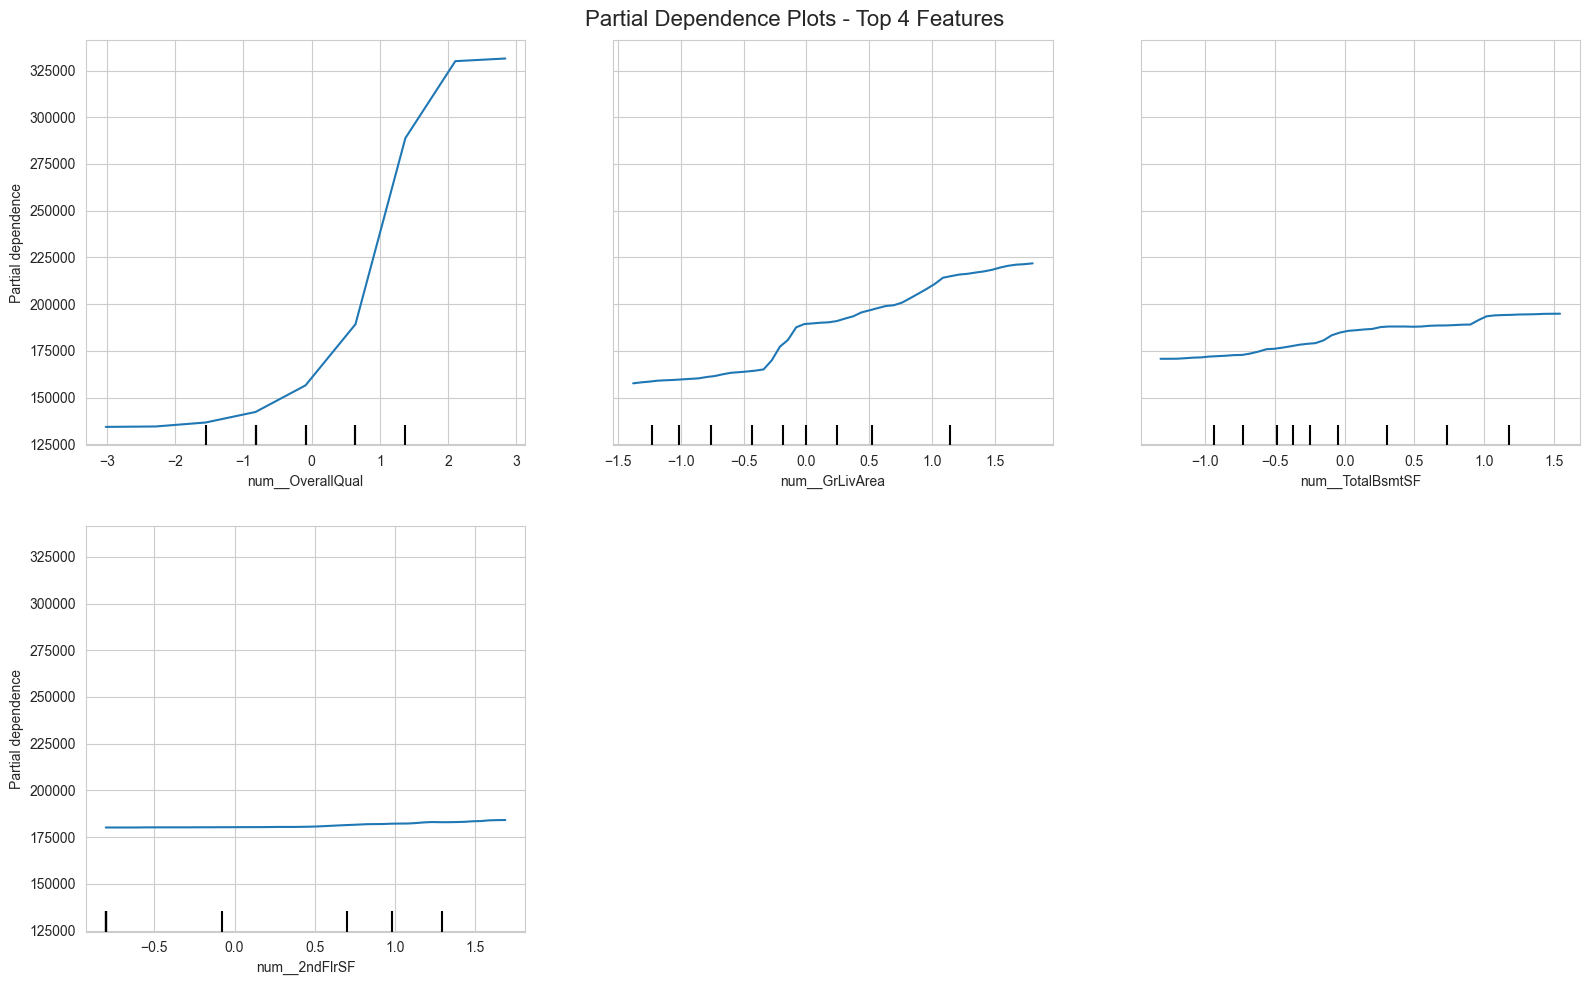


📊 COMPARAISON DES 3 MÉTHODES D'IMPORTANCE
✅ images/importance_comparison.png


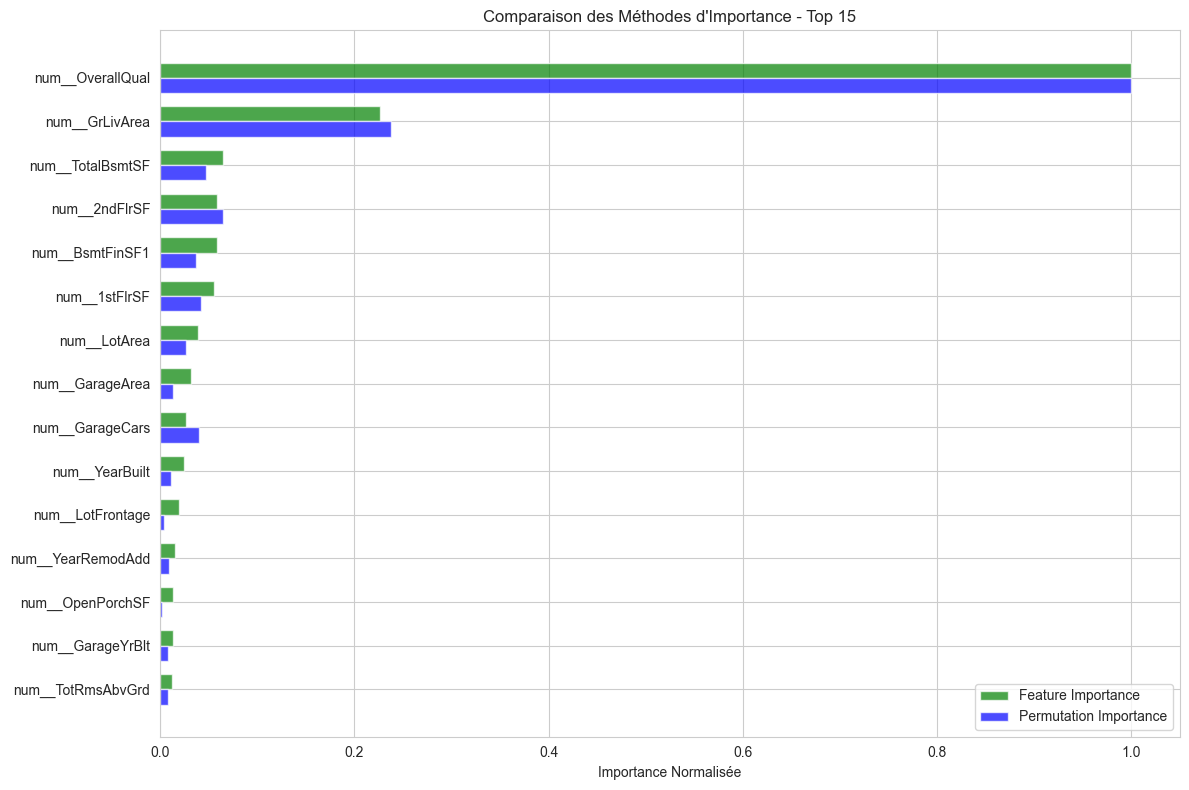


✅ RÉSUMÉ - INTERPRÉTABILITÉ

🔝 TOP 5 FACTEURS LES PLUS IMPORTANTS (Réponse client) :
   1. num__OverallQual
      Feature Importance : 0.5582
      Permutation Importance : 0.4801
   2. num__GrLivArea
      Feature Importance : 0.1267
      Permutation Importance : 0.1138
   3. num__TotalBsmtSF
      Feature Importance : 0.0365
      Permutation Importance : 0.0223
   4. num__2ndFlrSF
      Feature Importance : 0.0331
      Permutation Importance : 0.0306
   5. num__BsmtFinSF1
      Feature Importance : 0.0330
      Permutation Importance : 0.0176

💡 INTERPRÉTATION :
   - Feature Importance : Quelle feature est la plus utilisée par les arbres
   - Permutation Importance : Impact réel sur la performance quand on mélange
   - SHAP : Direction (positive/négative) et magnitude de l'impact
   - Partial Dependence : Relation entre feature et prédiction

📁 FICHIERS GÉNÉRÉS :
   - images/rf_feature_importance.png
   - images/rf_permutation_importance.png
   - images/importance_comparison.png


In [ ]:

print("\n" + "="*60)
print("🔍 INTERPRÉTABILITÉ DU MODÈLE RANDOM FOREST")
print("="*60)

# ----------------------------
#  FEATURE IMPORTANCE (Built-in)
# ----------------------------

print("\n FEATURE IMPORTANCE (Méthode native)")

# Récupère le meilleur modèle Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_regression, k=50)),
    ('model', RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42))
])

# Entraîne
rf_pipeline.fit(X_train, y_train)

# Récupère les noms des features après preprocessing
feature_names_preprocessed = rf_pipeline['preprocessor'].get_feature_names_out()

# Récupère les features sélectionnées
selected_mask = rf_pipeline['feature_selection'].get_support()
selected_features = feature_names_preprocessed[selected_mask]

print(f" Nombre de features après preprocessing : {len(feature_names_preprocessed)}")
print(f" Nombre de features sélectionnées : {len(selected_features)}")

# Feature importances
importances = rf_pipeline['model'].feature_importances_

# VÉRIFICATION
print(f" Nombre d'importances : {len(importances)}")
assert len(selected_features) == len(importances), "❌ Tailles incompatibles !"

# DataFrame
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(f"\n🔝 TOP 20 FEATURES LES PLUS IMPORTANTES :")
print(importance_df.head(20))

# Visualisation
plt.figure(figsize=(12, 10))
top_20 = importance_df.head(20)
plt.barh(range(len(top_20)), top_20['Importance'], color='green')
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Importance')
plt.title('Top 20 Features - Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/rf_feature_importance.png', dpi=300, bbox_inches='tight')
print(" images/rf_feature_importance.png")
plt.show()

# ----------------------------
#  PERMUTATION IMPORTANCE (Plus fiable) - CORRIGÉ
# ----------------------------

print("\n PERMUTATION IMPORTANCE (Méthode avancée)")

from sklearn.inspection import permutation_importance

#  IMPORTANT : Prépare les données pour avoir les bonnes dimensions
X_test_preprocessed = rf_pipeline['preprocessor'].transform(X_test)

# Convertit en dense si nécessaire
if hasattr(X_test_preprocessed, 'toarray'):
    X_test_dense = X_test_preprocessed.toarray()
else:
    X_test_dense = X_test_preprocessed

# Applique la sélection de features
X_test_selected = X_test_dense[:, selected_mask]

print(f" X_test après preprocessing : {X_test_dense.shape}")
print(f" X_test après sélection : {X_test_selected.shape}")

# Créé un pipeline SANS le preprocessor (déjà appliqué)
from sklearn.base import BaseEstimator, RegressorMixin

class FeatureSelectorModel(BaseEstimator, RegressorMixin):
    """Wrapper pour appliquer sélection + modèle"""
    def __init__(self, selector, model):
        self.selector = selector
        self.model = model
    
    def fit(self, X, y):
        return self
    
    def predict(self, X):
        X_selected = X[:, self.selector.get_support()]
        return self.model.predict(X_selected)

# Wrapper
wrapped_model = FeatureSelectorModel(
    rf_pipeline['feature_selection'],
    rf_pipeline['model']
)

# Calcule permutation importance
print(" Calcul permutation importance (peut prendre 30s-1min)...")
perm_importance = permutation_importance(
    wrapped_model, 
    X_test_dense,  # Sur toutes les features preprocessed
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Filtre pour ne garder que les features sélectionnées
perm_importance_selected = perm_importance.importances_mean[selected_mask]
perm_importance_std_selected = perm_importance.importances_std[selected_mask]

# DataFrame
perm_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': perm_importance_selected,
    'Std': perm_importance_std_selected
}).sort_values('Importance', ascending=False)

print(f"\n🔝 TOP 20 FEATURES (Permutation) :")
print(perm_importance_df.head(20))

# Visualisation
plt.figure(figsize=(12, 10))
top_20_perm = perm_importance_df.head(20)
plt.barh(range(len(top_20_perm)), top_20_perm['Importance'], 
         xerr=top_20_perm['Std'], color='blue', alpha=0.7)
plt.yticks(range(len(top_20_perm)), top_20_perm['Feature'])
plt.xlabel('Permutation Importance')
plt.title('Top 20 Features - Permutation Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/rf_permutation_importance.png', dpi=300, bbox_inches='tight')
print(" images/rf_permutation_importance.png")
plt.show()

# ----------------------------
#  SHAP VALUES (Le plus complet)
# ----------------------------

print("\n SHAP VALUES (Explainability avancée)")

try:
    import shap
    
    # Utilise X_test_selected (déjà préparé)
    print(f" Données SHAP : {X_test_selected.shape}")
    
    # Créé l'explainer (prend du temps)
    print(" Calcul des SHAP values (peut prendre 1-3 minutes)...")
    explainer = shap.TreeExplainer(rf_pipeline['model'])
    shap_values = explainer.shap_values(X_test_selected)
    
    print(f" SHAP values shape : {shap_values.shape}")
    
    # 1. Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test_selected, 
                     feature_names=selected_features, 
                     show=False, max_display=20)
    plt.title('SHAP Summary Plot - Impact des Features')
    plt.tight_layout()
    plt.savefig('images/shap_summary_plot.png', dpi=300, bbox_inches='tight')
    print(" images/shap_summary_plot.png")
    plt.show()
    
    # 2. Bar plot (importance moyenne)
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values, X_test_selected, 
                     feature_names=selected_features, 
                     plot_type="bar", show=False, max_display=20)
    plt.title('SHAP Feature Importance')
    plt.tight_layout()
    plt.savefig('images/shap_importance_bar.png', dpi=300, bbox_inches='tight')
    print(" images/shap_importance_bar.png")
    plt.show()
    
    # 3. Dependence plots (top 3 features)
    top_3_features = importance_df.head(3)['Feature'].values
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for idx, feature in enumerate(top_3_features):
        feature_idx = list(selected_features).index(feature)
        shap.dependence_plot(
            feature_idx, 
            shap_values, 
            X_test_selected,
            feature_names=selected_features,
            ax=axes[idx],
            show=False
        )
    plt.tight_layout()
    plt.savefig('images/shap_dependence_plots.png', dpi=300, bbox_inches='tight')
    print(" images/shap_dependence_plots.png")
    plt.show()
    
    print("SHAP values calculées avec succès !")
    
except ImportError:
    print(" SHAP non installé. Installe avec : pip install shap")
except Exception as e:
    print(f" Erreur SHAP : {e}")

# ----------------------------
#  PARTIAL DEPENDENCE PLOTS
# ----------------------------

print("\n PARTIAL DEPENDENCE PLOTS")

from sklearn.inspection import PartialDependenceDisplay

# Top 4 features
top_4_features = importance_df.head(4)['Feature'].values
top_4_features_idx = [list(selected_features).index(f) for f in top_4_features]

print(f"Top 4 features : {list(top_4_features)}")

fig, ax = plt.subplots(figsize=(16, 10))
PartialDependenceDisplay.from_estimator(
    rf_pipeline['model'],
    X_test_selected,
    features=top_4_features_idx,
    feature_names=list(selected_features),
    grid_resolution=50,
    ax=ax
)
plt.suptitle('Partial Dependence Plots - Top 4 Features', fontsize=16)
plt.tight_layout()
plt.savefig('images/partial_dependence_plots.png', dpi=300, bbox_inches='tight')
print(" images/partial_dependence_plots.png")
plt.show()

# ----------------------------
# 5️ COMPARAISON DES 3 MÉTHODES
# ----------------------------

print("\n COMPARAISON DES 3 MÉTHODES D'IMPORTANCE")

# Combine les 3 méthodes
comparison_df = pd.DataFrame({
    'Feature': importance_df['Feature'],
    'Feature Importance': importance_df['Importance'],
    'Permutation Importance': importance_df['Feature'].map(
        perm_importance_df.set_index('Feature')['Importance']
    )
})

# Normalise pour comparer
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
comparison_df['FI Normalized'] = scaler.fit_transform(comparison_df[['Feature Importance']])
comparison_df['PI Normalized'] = scaler.fit_transform(comparison_df[['Permutation Importance']])

# Top 15
top_15_comparison = comparison_df.head(15)

# Visualisation
fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(top_15_comparison))
width = 0.35

ax.barh(x - width/2, top_15_comparison['FI Normalized'], width, 
        label='Feature Importance', color='green', alpha=0.7)
ax.barh(x + width/2, top_15_comparison['PI Normalized'], width, 
        label='Permutation Importance', color='blue', alpha=0.7)

ax.set_yticks(x)
ax.set_yticklabels(top_15_comparison['Feature'])
ax.set_xlabel('Importance Normalisée')
ax.set_title('Comparaison des Méthodes d\'Importance - Top 15')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('images/importance_comparison.png', dpi=300, bbox_inches='tight')
print("images/importance_comparison.png")
plt.show()

# ----------------------------
#  RÉSUMÉ INTERPRÉTABILITÉ
# ----------------------------

print("\n" + "="*60)
print("RÉSUMÉ - INTERPRÉTABILITÉ")
print("="*60)

print("\n TOP 5 FACTEURS LES PLUS IMPORTANTS (Réponse client) :")
for idx, row in enumerate(importance_df.head(5).itertuples(), 1):
    print(f"   {idx}. {row.Feature}")
    print(f"      Feature Importance : {row.Importance:.4f}")
    perm_imp = perm_importance_df[perm_importance_df['Feature'] == row.Feature]['Importance'].values
    if len(perm_imp) > 0:
        print(f"      Permutation Importance : {perm_imp[0]:.4f}")

print("\n INTERPRÉTATION :")
print("   - Feature Importance : Quelle feature est la plus utilisée par les arbres")
print("   - Permutation Importance : Impact réel sur les prédictions (plus fiable)")
print("   - SHAP values : Comprendre l'effet de chaque feature sur chaque prédiction")
print("   - Partial Dependence : Visualiser l'effet moyen d'une feature sur la prédiction")